In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

For Project 3, we are operating under the following scenario:

An external online retail company, Le Shoppe, has requested assistance with identifying customers who may previously have shopped with their business, but haven't come back in a while.

They currently have limited outreach to these customers. 
- Once a year, their Marketing team runs a "welcome back" campaign where they send an email with a special discount code to customers who haven't shopped with them in 12 months.
- During quiet periods (when there aren't a lot of calls or tickets to respond to), their Customer Care team members are given a list to work from containing customer details who have been less active. The Customer Care team reach out to these customers and make contact with them, and are authorised to give them discounts and freebies where needed.

This company, Le Shoppe, has noticed recently that this is not the most effective means of reaching out to or identifying these customers. Both methods require a manual pull of a list from the system each time they need that list, and it requires someone on these teams with the knowledge and authority within the business to pull said list. The list may also be outdated by the time it reaches a customer care team member, or a resulting special offer has reached a customer.

The company is also unclear on what may be causing customers to stop shopping with them beyond individual feedback they have received from customers themselves. 

Le Shoppe has three primary goals for this particular endeavour:
1. A better process for identifying customers at risk of churning
2. Where possible, locate the underlying trend(s) that may be causing customers to churn
3. Suggestions and recommendations on how to improve their service to these customers

The primary stakeholders within Le Shoppe are the General Marketing Manager, the Customer Care Manager, and the Ecommerce Operations Manager.

## Marking Criteria (Notebook, 35%)
>  - A single professional and structured Jupyter notebook (pretend that you are submitting this to a potential client)
> - Include some EDA where needed, but focus primarily on robust experimentation with feature engineering, a variety of algorithms
> and their tuning, XAI, and providing rich analysis and interpretation at each step.
> - Make sure that you use a rich array of evaluation metrics and present all your modelling and accuracies from different approaches effectively.

## Notebook Sections

### Data Wrangling
1. <a id='part1a'>Churn dataset</a>: 
    - [Random Forest used initially](#datap_rf) for feature importances, paired with Correlation Matrix Heat Map for initial feature selection
        - [Fig 1](#fig1): Correlation Matrix Heat Map
    - [KMeans Clustering](#km_clustering) used to identify number of risk groups
        - [Fig 2](#fig2): Cluster Evaluation Metrics vs. Number of Clusters (k)
        - [Fig 3](#fig3): K-Means Clusters via UMAP
        - [Table 1](#Table1): Summary Statistics for Churn Data
        - [Table 2](#Table2): Cluster Summary
    - [Random Forest used again](#datap_rf2) to identify which features were the most important for kMeans clustered groups
        - [Fig 4](#fig4): Correlation Matrix Heat Map 2
    - **Feature selection**: features were selected from the above processes, and were based on feature importances, correlations, and relevance to groups determined by KMeans Clustering. The final set of features selected can be seen [here](#churn_feature_selection). 
2. <a id='part1b'>Customer Acquistion Cost dataset</a>: 
    - Features engineered:
        - CAC (Customer Acquisition Cost)
        - ROI (Return on Investment)
        - [Table 3](#Table3): Customer Acquisition Cost by Marketing Channel

### Modelling <a id="part2">
1. [CatBoost](#catboost)
    - Hyperparameter Tuning
        - [Depth](#cb_ht_depth), [Number of Iterations](#cb_ht_cb_ht_iterations), [Learning Rate](#cb_ht_lr), [Early Stopping Rounds](#cb_ht_es), [Grow Policy](#cb_ht_gp), [Regularisation](#cb_ht_re) (includes L2 regularisation, random strength and bagging temperature)
        - CB model 14's parameters appearing to be best fit for dataset
    - AUC-ROC
        - [Fig 5](#Fig5): ROC Curve for CatBoost Model 14 <span style="color:red;">[interpretation needed]</span>
2. [Random Forest](#randomforest) <a id='part2b'> </a>
    - Imputed missing values in the dataset based on median
    - Hyperparameter Tuning
        - Number of Estimators, Max Depth, Min Samples Split, Min Samples Leaf, Max Features, Class Weight
        - Feature Selection: 4 features dropped (Login_Frequency, Mobile_App_Usage, Wishlist_Items, Pages_Per_Session)
        - [Fig 14](#Fig14): Confusion Matrix for Random Forest
3. [XGBoost](#xgboost) <a id='part2c'> </a>
    - Hyperparameter Tuning
        - Number of Estimators, Max Depth, Learning Rate, Subsample, Colsample by tree, Min Child Weight
4. [LightGBM](#lightgbm) <a id='part2d'> </a>
    - Hyperparameter Tuning
        - Number of Estimators, Max Depth, Learning Rate, Num Leaves, Subsample, Colsample by tree
        - Quick comparison against CatBoost Model
5. [Revisiting Random Forest](#randomforest2) <a id='part2e'> </a>
    - Hyperparameter Tuning
        - Same parameters as before with less features
        - Feature Selection: 4 features retained (Lifetime_Value, Cart_Abandonment_Rate, Email_Open_Rate and Total_Purchases)
6. [Stacking](#stacking) - <a id='part2e'> </a>ensemble method with different base models
    - Feature selection: tested base model combinations with different sets of features and meta estimators
    - [Table](#Table): Stacking Model Performance Comparison (with focus on Recall)
7. [Model Comparison](#comparing_models)
    - Data reset, split into two sets of train and test (one with all features, one with less)
    - Best CatBoost, XGBoost, Random Forest, LightGBM and Stacking model parameters tested on the same data
    - [Table](#Table): Model Performance Comparison, values sorted by Recall
8. [Application of Risk Labels](#risk_labels) <a id='part2f'> </a>
    - Used determine_best_risk_thresholds() with best performing model to determine best split for low, medium and high risk labels
    - Engineered a 'Churn_Risk' feature based on predicted probabilities supplied by the model and threshold split determined by user-defined function

### Data Source(s)
- Singh, D. (n.d.). _Ecommerce Customer Behavior Dataset_. [Data set]. Kaggle. https://www.kaggle.com/datasets/dhairyajeetsingh/ecommerce-customer-behavior-dataset/data
- Hussam, A. (n.d.). _Customer Acquisition Cost Dataset_. [Data set]. Kaggle. https://www.kaggle.com/datasets/akramhussam/customer-acquisition-cost-dataset

### References
- _What is customer lifetime value (CLV)?_ https://www.ibm.com/think/topics/customer-lifetime-value
- _Customer Acquisition Cost (CAC)_ https://corporatefinanceinstitute.com/resources/accounting/customer-acquisition-cost-cac/

### Data and User-Defined Functions

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, f1_score, cohen_kappa_score
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from collections import Counter
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import shap

imputer = SimpleImputer(strategy='median')

C:\Users\lovet\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Get ratio
def get_ratio(a, b):
    decimal_ratio = a / b
    
    return f"{decimal_ratio:.1f}:1"

# Define risk thresholds
def assign_risk_tier(prob, lowtier, medtier):
    if prob < lowtier:
        return 'Low'
    elif prob < medtier:
        return 'Med'
    else:
        return 'High'

def determine_best_risk_thresholds(y_proba, y_test, low_thresholds, med_thresholds, chosen_metric='f1_low'):
    y_test_mapped = np.where(y_test == 0, 'Low', 'High')
    results_list = []
    
    for low_t in low_thresholds:
        for med_t in med_thresholds:
            if low_t >= med_t:
                continue
                
            y_pred_risk = np.array([assign_risk_tier(p, low_t, med_t) for p in y_proba])
            
            # Get classification report as dict object
            report = classification_report(y_test_mapped,y_pred_risk,labels=['Low', 'Med', 'High'],zero_division=0,output_dict=True)
            
            # Save the parameters from this test into a dict row
            results_list.append({
                'low_cutoff': low_t,
                'med_cutoff': med_t,
                'precision (low)': report['Low']['precision'],
                'recall (low)': report['Low']['recall'],
                'f1-score (low)': report['Low']['f1-score'],
                'precision (high)': report['High']['precision'],
                'recall (high)': report['High']['recall'],
                'f1-score (high)': report['High']['f1-score'],
                'accuracy': report['accuracy']
            })
            
    # Put all the test results into a dataframe
    df_results = pd.DataFrame(results_list)
    
    # Select metric to define as 'best'
    if chosen_metric == 'f1_low':
        target_metric = 'f1-score (low)'
    elif chosen_metric == 'f1_high':
        target_metric = 'f1-score (high)'
    elif chosen_metric == 'precision_low':
        target_metric = 'precision (low)'
    elif chosen_metric == 'precision_high':
        target_metric = 'precision (high)'
    elif chosen_metric == 'recall_low':
        target_metric = 'recall (low)'
    elif chosen_metric == 'recall_high':
        target_metric = 'recall (high)'
    elif chosen_metric == 'accuracy':
        target_metric = 'accuracy'

    # Get the best row
    df_best = df_results.sort_values(by=target_metric, ascending=False).head(1)

    results = pd.DataFrame({"Metric": ["Precision","Recall","F1 Score"],
               "Low": [df_best['precision (low)'].iloc[0], df_best['recall (low)'].iloc[0], df_best['f1-score (low)'].iloc[0]],
               "High": [df_best['precision (high)'].iloc[0], df_best['recall (high)'].iloc[0], df_best['f1-score (high)'].iloc[0]]})

    results.set_index('Metric', inplace=True)
    results.index.rename('', inplace=True)
    print(f"""Best Results
----------------------------------------------
Low threshold: {df_best['low_cutoff'].iloc[0]}
Medium threshold: {df_best['med_cutoff'].iloc[0]}
Accuracy: {df_best['accuracy'].iloc[0]}
{results}""")

    return df_best['low_cutoff'].iloc[0], df_best['med_cutoff'].iloc[0]

def apply_risk_label(row):
    if row['churn_probability'] < 0.3:
        return 'Low'
    elif row['churn_probability'] > 0.3 and row['churn_probability'] <= 0.4:
        return 'Medium'
    else:
        return 'High'

def specificity_score(y_true, y_pred):
    return recall_score(y_true, y_pred, pos_label=0)

---

# Churn

In [4]:
churn_dataset = pd.read_csv('datasets/ecommerce_customer_churn_dataset.csv')

In [5]:
churn_dataset.dtypes

Age                              float64
Gender                            object
Country                           object
City                              object
Membership_Years                 float64
Login_Frequency                  float64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Cart_Abandonment_Rate            float64
Wishlist_Items                   float64
Total_Purchases                  float64
Average_Order_Value              float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Lifetime_Value                   float64
Credit_Balance                   float64
Churned                            int64
Signup_Quarter  

In [6]:
churn_dataset.isna().sum()

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

<a id='datap_rf'> </a>
How many of these features are 'important' (and how many of them can we just delete if they're not and contain too many NaNs)? <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

In [7]:
# Random Forest Classifier doesn't like categorical values
encoder = OneHotEncoder(sparse_output=False)
encoded_array = encoder.fit_transform(churn_dataset[['Gender','Country','City','Signup_Quarter']])

encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['Gender','Country','City','Signup_Quarter']))
churn_dataset_encoded = churn_dataset.drop(['Gender','Country','City','Signup_Quarter'], axis=1)
churn_dataset_encoded = pd.concat([churn_dataset_encoded, encoded_df], axis=1)

In [8]:
y = churn_dataset_encoded['Churned']
X = churn_dataset_encoded.drop('Churned', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
rf_helper = RandomForestClassifier(n_estimators=100, random_state=42)
rf_helper.fit(X_train, y_train)

importances = rf_helper.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

In [10]:
top20feature_importance_df = feature_importance_df.head(20)
top20feature_importance_df

,Feature,Importance
18,Lifetime_Value,0.111573
13,Customer_Service_Calls,0.104860
5,Cart_Abandonment_Rate,0.081476
0,Age,0.062750
10,Discount_Usage_Rate,0.057891
9,Days_Since_Last_Purchase,0.051831
12,Email_Open_Rate,0.046456
8,Average_Order_Value,0.044633
7,Total_Purchases,0.043806
3,Session_Duration_Avg,0.042794


<a id='fig1'>Fig 1</a>: Correlation Matrix Heat Map <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

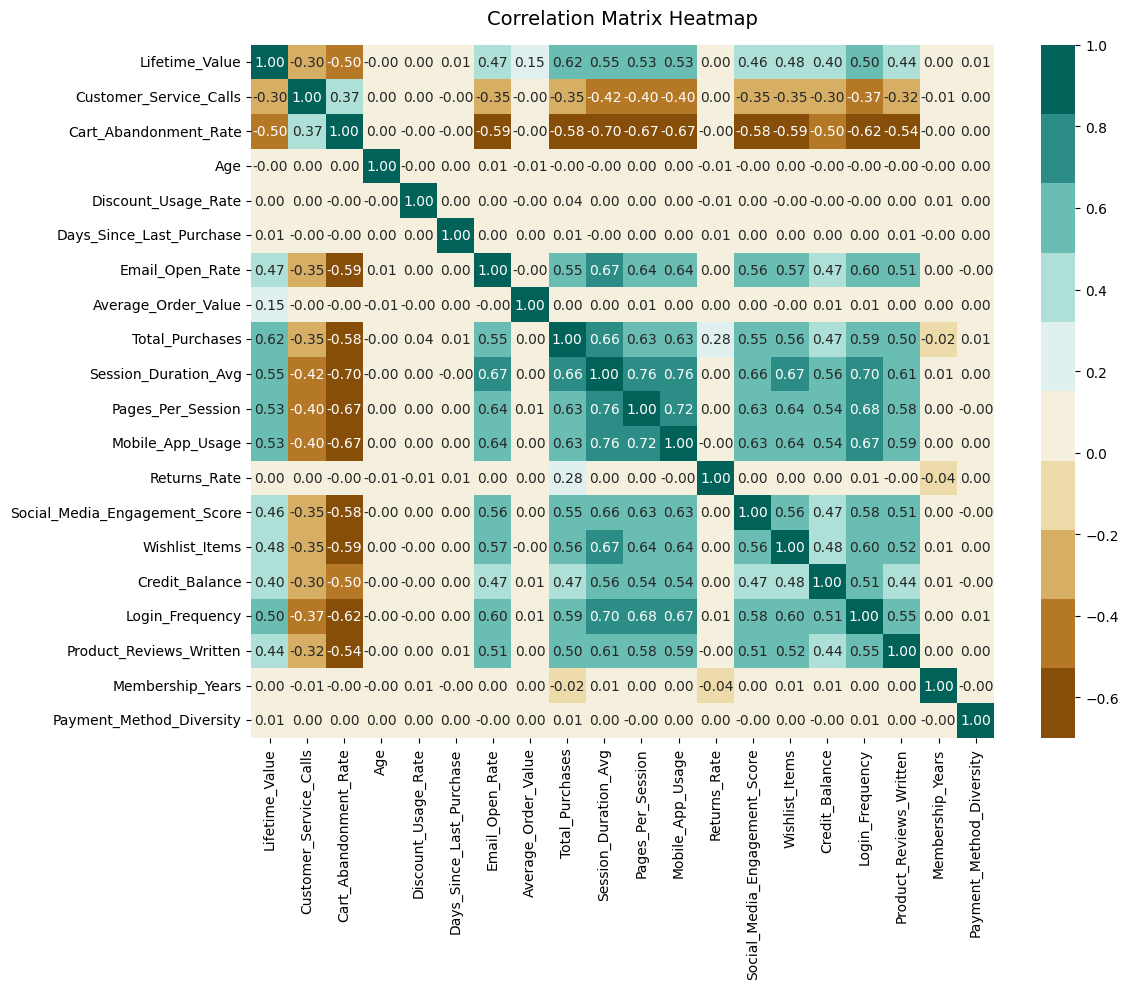

In [11]:
feature_names_top20 = top20feature_importance_df['Feature'].tolist()

corr_matrix = churn_dataset_encoded[feature_names_top20].corr()

plt.figure(figsize=(12, 10))
colormap = sns.color_palette("BrBG",10)

# Draw the heatmap
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap=colormap)

plt.title("Correlation Matrix Heatmap", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Based on the above diagnostics, these are the best features to select/work with, so far:

**Strongest feature:** Lifetime_Value

**Supporting features (highest correlation):**
- Total_Purchases
- Session_Duration_Average
- Pages_Per_Session
- Mobile_App_Usage
- Login_Frequency
- Cart_Abandonment_Rate

**Possibly Helpful/Remains to be seen (moderate correlation)**
- Social_Media_Engagement_Score
- Wishlist_Items
- Credit_Balance
- Product_Reviews_Written
- Email_Open_Rate

**Questionable/Not Super Helpful (low correlation):**
- Average_Order_Value
- Returns_Rate
- Customer_Service_Calls

**Features we can absolutely drop (nil or next-to-nil correlation):**
- Age
- Discount_Usage_Rate
- Days_Since_Last_Purchase
- Membership_Years
- Payment_Method_Diversity

In [12]:
columns_to_initially_keep = ['Gender','Country','City'] + feature_names_top20 + ['Churned']
churn_df = churn_dataset[columns_to_initially_keep]
columns_to_drop = ['Age','Discount_Usage_Rate','Days_Since_Last_Purchase','Membership_Years','Payment_Method_Diversity','Customer_Service_Calls']
churn_df = churn_df.drop(columns=columns_to_drop)
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Gender                         50000 non-null  object 
 1   Country                        50000 non-null  object 
 2   City                           50000 non-null  object 
 3   Lifetime_Value                 50000 non-null  float64
 4   Cart_Abandonment_Rate          50000 non-null  float64
 5   Email_Open_Rate                47472 non-null  float64
 6   Average_Order_Value            50000 non-null  float64
 7   Total_Purchases                50000 non-null  float64
 8   Session_Duration_Avg           46601 non-null  float64
 9   Pages_Per_Session              47000 non-null  float64
 10  Mobile_App_Usage               45000 non-null  float64
 11  Returns_Rate                   45509 non-null  float64
 12  Social_Media_Engagement_Score  44000 non-null 

---

## Risk Group Identification

<a id='km_clustering'> </a>
### Kmeans Clustering

As a means of identifying how to split our dataset for prediction analysis, we are employing the KMeans Clustering algorithm to see how we can best segregate the customers, and how many risk groups we can split them into.

<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

In [13]:
# Keep only continuous labels (no categorical/encoded)
# Drop the nil correlations
kmeans_df = churn_dataset.drop(columns=['Age','Gender','Country','City','Signup_Quarter','Returns_Rate','Discount_Usage_Rate','Days_Since_Last_Purchase','Membership_Years','Payment_Method_Diversity','Customer_Service_Calls']).copy()
kmeans_df.dropna(inplace=True) # Drops nearly half the dataset, just FYI
y_kmeans = kmeans_df['Churned']
X_kmeans = kmeans_df.drop('Churned', axis=1)

scaler = StandardScaler()
X_kmeans_scaled = scaler.fit_transform(X_kmeans)

Use indexing to see the optimal number of groups

In [14]:
k_range = range(2, 7) # Check range of 2 - 7 clusters
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for k in k_range:
    km_model = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km_model.fit(X_kmeans_scaled)
    results = km_model.predict(X_kmeans_scaled)

    silhouette_scores.append(metrics.silhouette_score(X_kmeans_scaled, results))
    davies_bouldin_scores.append(metrics.davies_bouldin_score(X_kmeans_scaled, results))
    calinski_harabasz_scores.append(metrics.calinski_harabasz_score(X_kmeans_scaled, results))

<a id='fig2'>Fig 2</a>: Cluster Evaluation Metrics vs. Number of Clusters (k) <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

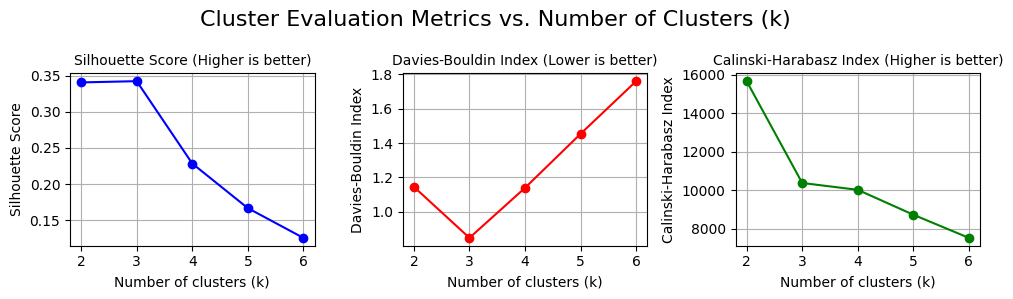

In [15]:
fig = plt.figure(figsize=(10, 3))
gs = gridspec.GridSpec(1, 3, figure=fig, height_ratios=[1])
fig.suptitle('Cluster Evaluation Metrics vs. Number of Clusters (k)', fontsize=16)

ax1 = fig.add_subplot(gs[0, 0]) # Row 0, Column 0
# Silhouette Plot
ax1.plot(k_range, silhouette_scores, 'bo-')
ax1.set_xlabel('Number of clusters (k)', fontsize=10)
ax1.set_ylabel('Silhouette Score', fontsize=10)
ax1.set_title('Silhouette Score (Higher is better)', fontsize=10)
ax1.grid(True)

ax2 = fig.add_subplot(gs[0, 1]) # Row 0, Column 1
# Davies-Bouldin Plot
ax2.plot(k_range, davies_bouldin_scores, 'ro-')
ax2.set_xlabel('Number of clusters (k)', fontsize=10)
ax2.set_ylabel('Davies-Bouldin Index', fontsize=10)
ax2.set_title('Davies-Bouldin Index (Lower is better)', fontsize=10)
ax2.grid(True)

ax3 = fig.add_subplot(gs[0, 2]) # Row 0, Column 2
# Calinski-Harabasz Plot
ax3.plot(k_range, calinski_harabasz_scores, 'go-')
ax3.set_xlabel('Number of clusters (k)', fontsize=10)
ax3.set_ylabel('Calinski-Harabasz Index', fontsize=10)
ax3.set_title('Calinski-Harabasz Index (Higher is better)', fontsize=10)
ax3.grid(True)

plt.tight_layout(); plt.show()

From the above plots, we can determine the optimal number for k is most likely 3. 3 is (just barely) the highest Silhouette Score, the lowest (preferred) option in the Davies-Bouldin Index, and the 'elbow' in the Calinski-Harabasz Index (where the rate of improvement is minimal past this point as k increases).

In [16]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

cluster_labels = kmeans.fit_predict(X_kmeans_scaled)

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_kmeans_scaled)

<a id='fig3'>Fig 3</a>: K-Means Clusters via UMAP <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

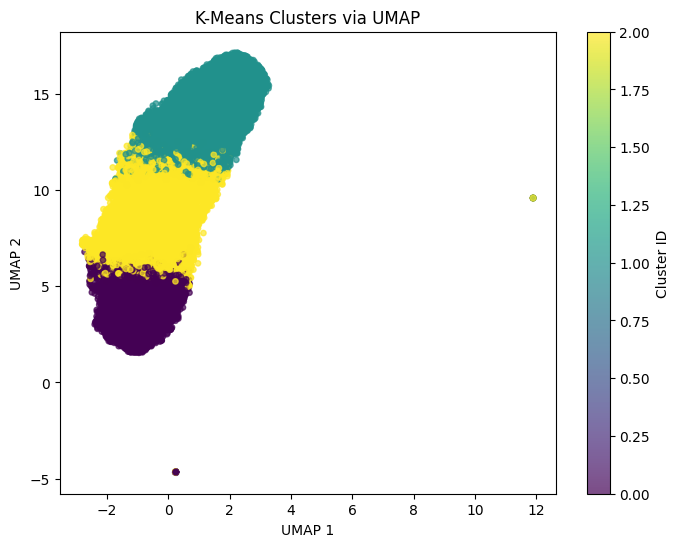

In [17]:
plt.figure(figsize=(8, 6)); scatter = plt.scatter(X_umap[:, 0],X_umap[:, 1],c=cluster_labels,cmap="viridis",s=15,alpha=0.7)
plt.colorbar(scatter, label="Cluster ID"); plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2"); plt.title("K-Means Clusters via UMAP"); plt.show()

Most of the data forms a single bean structure along the UMAP coordinates. This is probably reflective of continuous data, rather than distinctly separated groups. There are a couple of outliers which may require a bit of looking into to see if they're valid, or not.

There are weird slices, instead of groups/clusters, and there aren't really any clear "gaps" between the data points. There might be a bit of overlap between the groups identified, depending on the data point.

In [18]:
kmean_groups = X_kmeans.copy(); kmean_groups['Cluster'] = cluster_labels
kmean_groups['Churned'] = y_kmeans

# Calculate the average values for each cluster
cluster_summary = kmean_groups.groupby('Cluster').mean(); 
cluster_table = cluster_summary.sort_values(by='Churned', ascending=True)

In [19]:
summary_values = {"Feature": ['Login_Frequency','Session_Duration_Avg', 'Pages_Per_Session', 'Wishlist_Items', 
                          'Total_Purchases','Average_Order_Value','Email_Open_Rate','Product_Reviews_Written',
                          'Social_Media_Engagement_Score','Mobile_App_Usage','Lifetime_Value','Credit_Balance','Churned'],
    "Min": [kmeans_df.Login_Frequency.min(), kmeans_df.Session_Duration_Avg.min(), kmeans_df.Pages_Per_Session.min(), kmeans_df.Wishlist_Items.min(), kmeans_df.Total_Purchases.min(), kmeans_df.Average_Order_Value.min(), kmeans_df.Email_Open_Rate.min(), kmeans_df.Product_Reviews_Written.min(), kmeans_df.Social_Media_Engagement_Score.min(), kmeans_df.Mobile_App_Usage.min(), kmeans_df.Lifetime_Value.min(), kmeans_df.Credit_Balance.min(), kmeans_df.Churned.min()],
    "Q1": [kmeans_df.Login_Frequency.quantile(0.25), kmeans_df.Session_Duration_Avg.quantile(0.25), kmeans_df.Pages_Per_Session.quantile(0.25), kmeans_df.Wishlist_Items.quantile(0.25), kmeans_df.Total_Purchases.quantile(0.25), kmeans_df.Average_Order_Value.quantile(0.25), kmeans_df.Email_Open_Rate.quantile(0.25), kmeans_df.Product_Reviews_Written.quantile(0.25), kmeans_df.Social_Media_Engagement_Score.quantile(0.25), kmeans_df.Mobile_App_Usage.quantile(0.25), kmeans_df.Lifetime_Value.quantile(0.25), kmeans_df.Credit_Balance.quantile(0.25), kmeans_df.Churned.quantile(0.25)],
    "Median": [kmeans_df.Login_Frequency.median(), kmeans_df.Session_Duration_Avg.median(), kmeans_df.Pages_Per_Session.median(), kmeans_df.Wishlist_Items.median(), kmeans_df.Total_Purchases.median(), kmeans_df.Average_Order_Value.median(), kmeans_df.Email_Open_Rate.median(), kmeans_df.Product_Reviews_Written.median(), kmeans_df.Social_Media_Engagement_Score.median(), kmeans_df.Mobile_App_Usage.median(), kmeans_df.Lifetime_Value.median(), kmeans_df.Credit_Balance.median(), kmeans_df.Churned.median()],    
    "Q3": [kmeans_df.Login_Frequency.quantile(0.75), kmeans_df.Session_Duration_Avg.quantile(0.75), kmeans_df.Pages_Per_Session.quantile(0.75), kmeans_df.Wishlist_Items.quantile(0.75), kmeans_df.Total_Purchases.quantile(0.75), kmeans_df.Average_Order_Value.quantile(0.75), kmeans_df.Email_Open_Rate.quantile(0.75), kmeans_df.Product_Reviews_Written.quantile(0.75), kmeans_df.Social_Media_Engagement_Score.quantile(0.75), kmeans_df.Mobile_App_Usage.quantile(0.75), kmeans_df.Lifetime_Value.quantile(0.75), kmeans_df.Credit_Balance.quantile(0.75), kmeans_df.Churned.quantile(0.75)],
    "Max": [kmeans_df.Login_Frequency.max(), kmeans_df.Session_Duration_Avg.max(), kmeans_df.Pages_Per_Session.max(), kmeans_df.Wishlist_Items.max(), kmeans_df.Total_Purchases.max(), kmeans_df.Average_Order_Value.max(), kmeans_df.Email_Open_Rate.max(), kmeans_df.Product_Reviews_Written.max(), kmeans_df.Social_Media_Engagement_Score.max(), kmeans_df.Mobile_App_Usage.max(), kmeans_df.Lifetime_Value.max(), kmeans_df.Credit_Balance.max(), kmeans_df.Churned.max()]}

summary_stats = pd.DataFrame(summary_values)

<a id='Table1'>Table 1</a>: Summary Statistics for Churn Data <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

In [20]:
summary_stats.sort_values('Max', ascending=False).style.set_caption('Summary Statistics for Churn Data').format(precision=2)

,Feature,Min,Q1,Median,Q3,Max
5,Average_Order_Value,26.87,87.04,112.21,143.75,9487.43
10,Lifetime_Value,0.00,833.23,1299.56,1933.79,8987.24
11,Credit_Balance,0.00,1122.00,1987.00,2872.50,7160.00
4,Total_Purchases,-13.00,9.00,13.00,17.00,127.40
8,Social_Media_Engagement_Score,0.00,14.50,29.20,44.90,100.00
6,Email_Open_Rate,0.00,10.60,20.60,31.20,91.70
1,Session_Duration_Avg,1.00,20.10,27.30,35.20,72.10
9,Mobile_App_Usage,0.00,13.20,19.60,26.40,61.90
0,Login_Frequency,0.00,6.00,12.00,18.00,46.00
2,Pages_Per_Session,1.00,6.30,8.80,11.60,23.20


From the above, our outliers are probably coming from Average_Order_Value, Lifetime_Value or Credit_Balance. There does appear to be negative amount(s) for Total_Purchases which I am unclear on, but can only assume that's related to refunds.

<a id='Table2'>Table 2</a>: Cluster Summary <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

In [21]:
cluster_table.style.set_caption('Cluster Summary').format(precision=2)

,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Email_Open_Rate,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Lifetime_Value,Credit_Balance,Churned
Cluster,,,,,,,,,,,,,,
0,21.81,42.50,13.87,36.39,8.30,21.74,124.44,38.36,5.56,54.89,32.33,2418.30,3291.82,0.20
2,13.42,29.80,9.64,52.97,4.91,14.51,123.83,23.24,3.26,33.21,21.50,1580.46,2167.09,0.20
1,6.21,18.76,5.90,68.15,2.12,8.31,119.78,10.99,1.40,15.59,12.29,907.72,1249.04,0.38


Our 3 clusters do have pretty distinct average values, and show a clear overall pattern. There is a positive association between churn risk and cart_abandoment_rate, where the churn risk increases as the cart_abandonment_rate increases. There is a negative association between all other features and churn risk (where the feature (ie. Login_Frequency) increases, churn risk decreases). 

This shows there is some promise for being able to group the Churn dataset into 3 risk categories: low, medium and high (where low is a low risk of churn, and high is a high risk of churn).

In [22]:
risk_map = {0: "low", 1: "high", 2: "medium"}
kmean_groups['Churn_Risk'] = kmean_groups['Cluster'].map(risk_map)
kmean_groups.head(5)

,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Email_Open_Rate,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Lifetime_Value,Credit_Balance,Cluster,Churned,Churn_Risk
0,14.0,27.4,6.0,50.6,3.0,9.0,94.72,17.9,4.0,16.3,20.8,953.33,2278.0,2,0,medium
3,10.0,38.4,14.8,41.7,9.0,15.0,147.33,41.4,5.0,85.9,31.0,2340.92,2674.0,0,0,low
5,6.0,21.9,6.9,74.4,0.0,12.0,190.97,16.0,2.0,14.3,11.2,1995.43,2418.0,1,1,high
6,24.0,46.4,13.9,36.2,5.0,20.0,169.58,35.5,6.0,68.8,42.9,3003.57,2657.0,0,0,low
9,13.0,31.3,5.4,62.6,3.0,9.0,90.95,11.7,1.0,13.5,21.5,807.84,977.0,1,0,high


KMeans does not have 'probabilities', so we'll use GM to get the probabilities from the kmeans clustering results.

In [23]:
gmm = GaussianMixture(n_components=3, means_init=kmeans.cluster_centers_)
gmm.fit(X_kmeans_scaled) 

probabilities = gmm.predict_proba(X_kmeans_scaled)

prob_cols = [f'cluster_{i}_prob' for i in range(gmm.n_components)]
prob_df = pd.DataFrame(probabilities, columns=prob_cols, index=kmeans_df.index)

df_with_probs = pd.concat([kmeans_df, prob_df], axis=1)

prob_cols = ['cluster_0_prob', 'cluster_1_prob', 'cluster_2_prob']

df_with_probs['predicted_cluster'] = gmm.predict(X_kmeans_scaled)
df_with_probs['max_prob'] = df_with_probs[prob_cols].max(axis=1) # The highest probability out of each cluster

# Check the model's overall average confidence
baseline_confidence = df_with_probs['max_prob'].mean()

# Check the model's ambiguity rate (Customers the model struggled to place)
ambiguity_rate = (df_with_probs['max_prob'] < 0.60).mean()

# Extract customers where the baseline model is 95%+ confident
high_confidence_df = df_with_probs[df_with_probs['max_prob'] > 0.95]

# Extract customers where the baseline model is 70%+ confident
med_confidence_df = df_with_probs[(df_with_probs['max_prob'] > 0.70) & (df_with_probs['max_prob'] <= 0.95)]

# Extract customers where the baseline model is less than 70% confident
low_confidence_df = df_with_probs[df_with_probs['max_prob'] <= 0.70]

print(f"Baseline Average Confidence: {baseline_confidence:.2%}")
print(f"Baseline Ambiguity Rate: {ambiguity_rate:.2%}")
print(f"High Confidence Segments: {len(high_confidence_df)} out of {len(df_with_probs)} rows")
print(f"Medium Confidence Segments: {len(med_confidence_df)} out of {len(df_with_probs)} rows")
print(f"Low Confidence Segments: {len(low_confidence_df)} out of {len(df_with_probs)} rows")

Baseline Average Confidence: 91.96%
Baseline Ambiguity Rate: 4.76%
High Confidence Segments: 16495 out of 25123 rows
Medium Confidence Segments: 6160 out of 25123 rows
Low Confidence Segments: 2468 out of 25123 rows


In [24]:
low_confidence_indices = low_confidence_df.index
difficult_df = churn_df.iloc[low_confidence_indices]
difficult_df.to_csv('datasets/difficult_cases.csv')

<a id='datap_rf2'> </a>
Of the features used for grouping, which features are the biggest factors in deciding which groups kMeans has put each data point into? <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

In [25]:
y_labels = kmean_groups['Cluster']
X_features = kmean_groups.drop(['Cluster','Churned','Churn_Risk'], axis=1, errors='ignore')

rf_helper2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_helper2.fit(X_features, y_labels)

importances = rf_helper2.feature_importances_
feature_names = X_features.columns
feature_importance_df2 = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

feature_importance_df2 = feature_importance_df2.sort_values(by='Importance', ascending=False)
feature_importance_df2

,Feature,Importance
1,Session_Duration_Avg,0.174538
5,Total_Purchases,0.159901
10,Mobile_App_Usage,0.132064
2,Pages_Per_Session,0.117986
3,Cart_Abandonment_Rate,0.079248
0,Login_Frequency,0.066481
4,Wishlist_Items,0.058934
7,Email_Open_Rate,0.058292
9,Social_Media_Engagement_Score,0.044752
12,Credit_Balance,0.033638


<a id='fig4'>Fig 4</a>: Correlation Matrix Heat Map 2<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

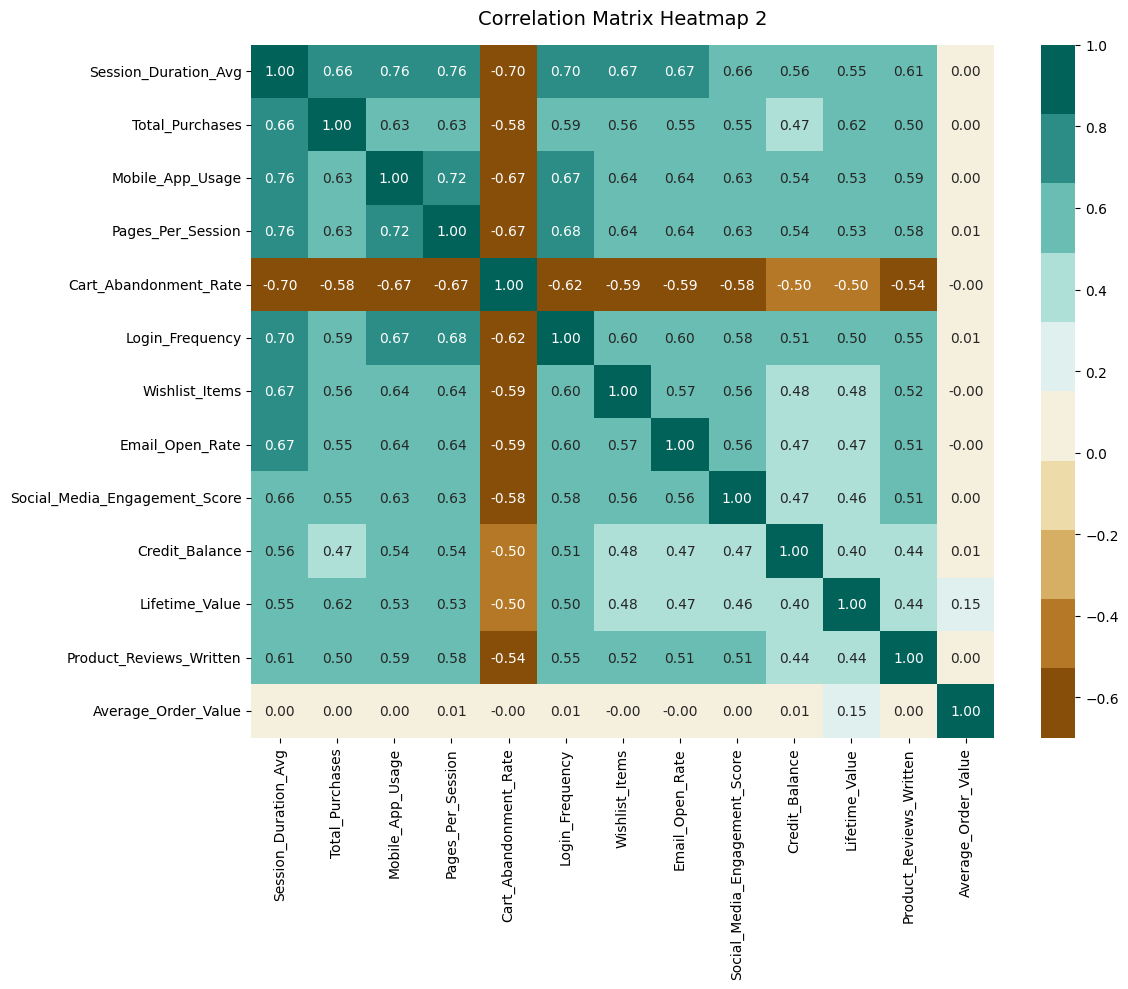

In [26]:
feature_names_grouping = feature_importance_df2['Feature'].tolist()

corr_matrix = churn_dataset_encoded[feature_names_grouping].corr()

plt.figure(figsize=(12, 10))
colormap = sns.color_palette("BrBG",10)

# Draw the heatmap
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap=colormap)

plt.title("Correlation Matrix Heatmap 2", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

When it comes to grouping, based on the initial KMeans Clustering results, the important features are:

**Supporting features (highest correlation):**
- Session_Duration_Avg
- Total_Purchases
- Mobile_App_Usage
- Pages_Per_Session
- Cart_Abandonment_Rate
- Login_Frequency
- Wishlist_Items
- Email_Open_Rate

**Probably helpful (moderate correlation)**
- Lifetime_Value
- Social_Media_Engagement_Score
- Credit_Balance
- Product_Reviews_Written

**Droppable (very low correlation):**
- Average_Order_Value

In [27]:
print(churn_dataset.columns)

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')


In [28]:
columns_to_keep = ['Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 
                   'Total_Purchases', 'Email_Open_Rate', 'Mobile_App_Usage', 'Lifetime_Value', 'Credit_Balance', 'Churned']
churn_df = churn_dataset[columns_to_keep]
churn_df.to_csv('datasets/churn_data_ready.csv', index=False)

<a id='churn_feature_selection'> </a>
Final feature selection: features were selected from the original Churn dataset via the above processes. Feature selection was based on the results of Random Forest feature importances, correlation heat maps, and relevance to groups determined by KMeans Clustering. <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

In [29]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Login_Frequency        50000 non-null  float64
 1   Session_Duration_Avg   46601 non-null  float64
 2   Pages_Per_Session      47000 non-null  float64
 3   Cart_Abandonment_Rate  50000 non-null  float64
 4   Wishlist_Items         46000 non-null  float64
 5   Total_Purchases        50000 non-null  float64
 6   Email_Open_Rate        47472 non-null  float64
 7   Mobile_App_Usage       45000 non-null  float64
 8   Lifetime_Value         50000 non-null  float64
 9   Credit_Balance         44500 non-null  float64
 10  Churned                50000 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 4.2 MB


---

<a id='part1b'> </a>
# Customer Acquisition Cost
While this is a smaller dataset, it should be helpful to illustrate the cost(s) of acquiring a new customer. The formula for this is
$$\text{Customer Acquisition Cost} = \frac{\text{Sales and Marketing Costs}}{\text{Number of New Customers}}$$

The thought process behind this is that when a customer churns, a company has to spend money on advertising all over again to acquire a new customer. This results in net-zero growth, rather than expansion.

In [30]:
customer_acquistion_cost_df = pd.read_csv('datasets/customer_acquisition_cost_dataset.csv')
customer_acquistion_cost_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        500 non-null    object 
 1   Marketing_Channel  500 non-null    object 
 2   Marketing_Spend    500 non-null    float64
 3   New_Customers      500 non-null    int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 15.8+ KB


In [31]:
channel_data = customer_acquistion_cost_df.groupby('Marketing_Channel')[['Marketing_Spend','New_Customers']].sum()
channel_data['CAC'] = channel_data['Marketing_Spend'] / channel_data['New_Customers']
channel_data.reset_index(inplace=True)
average_cac = channel_data['CAC'].mean()
cac_metrics1 = {"Metric": ["Average CAC - all channels"] + [f" - {channel}" for channel in channel_data['Marketing_Channel']],
                "Value": [average_cac] + channel_data['CAC'].tolist()}
print(f"The average cost to acquire a new customer across all marketing channels is ${average_cac:.2f}")

The average cost to acquire a new customer across all marketing channels is $103.04


From the above, we can see that the average customer acquisition cost across all marketing channels is $103.04. This means that, for each new customer, the company is spending an average of $103.04 to acquire them. The actual cost per customer ranges between $99.78 (customers acquired through Online Ads) and $107.18 (for customers acquired via Email Marketing).

## Return on Investment
The Churn dataset provides a useful feature for calculating ROI: Lifetime_Value 

ROI(%) = $\frac{\text{Customer Revenue - CAC}}{\text{CAC}}\times100$

https://chartmogul.com/saas-metrics/ltv/

In [32]:
# Calculate Average Revenue Per Customer for original churn_df
average_revenue_per_customer = churn_dataset['Lifetime_Value'].mean()
print(f"The average revenue per customer is ${average_revenue_per_customer:.2f}")

The average revenue per customer is $1440.63


In [33]:
channel_data['ROI'] = ((average_revenue_per_customer - channel_data['CAC']) / channel_data['CAC']) * 100
cac_metrics2 = {"Metric": ["Return on Investment - all channels"] + [f" - {channel}" for channel in channel_data['Marketing_Channel']] + ["LTV:CAC Ratio"], 
                "Value": [channel_data['ROI'].mean()] + channel_data['ROI'].tolist() + [get_ratio(average_revenue_per_customer, channel_data['CAC'].iloc[0])]}

<a id='Table3'>Table 3</a>: Customer Acquisition Cost by Marketing Channel <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1b))</span>

In [34]:
channel_data.style.set_caption('Customer Acquisition Cost by Marketing Channel').format(precision=2)

,Marketing_Channel,Marketing_Spend,New_Customers,CAC,ROI
0,Email Marketing,384034.64,3583,107.18,1244.09
1,Online Ads,388747.87,3896,99.78,1343.78
2,Referral,391420.51,3904,100.26,1336.87
3,Social Media,383160.25,3652,104.92,1273.10


In [35]:
print(f"The LTV:CAC ratio is {get_ratio(average_revenue_per_customer, channel_data['CAC'].iloc[0])}")

The LTV:CAC ratio is 13.4:1


This means that for every $1 spent on Marketing, $13.40 is earned.

## Impacts of Churn on Revenue
$\text{Revenue Churn} = (\frac{\text{Lost Revenue from Churned Customers}}{\text{Total Revenue at Start}})\times100$

$\text{Repeat Purchase Rate} = (\frac{\text{Number of Customers who made 2+ Purchases}}{\text{Total Number of Unique Customers}})\times100$

In [36]:
transaction_data = pd.read_csv('datasets/transactions.csv')
transaction_data['Transaction_Date'] = pd.to_datetime(transaction_data['Transaction_Date'], format='mixed')
transaction_data.dropna()

,Transaction_Date,Transaction_ID,Transaction_Type,Customer_ID,First Name,Last Name,Age,Gender,Amount,Discount_Amount,Month,Year_Month
0,2023-01-01 00:00:35,TX000002,Purchase,CX29573,Sage,D'Arripe,42,Female,525.18,0.00,1,2023-01
1,2023-01-01 00:01:11,TX000003,Purchase,CX24909,Gwen,Takahashi,18,Female,512.95,0.00,1,2023-01
2,2023-01-01 00:11:22,TX000013,Purchase,CX29887,Gavin,von Luhren,42,Male,111.34,0.00,1,2023-01
3,2023-01-01 00:19:10,TX000025,Purchase,CX19032,River,Zhu,35,Female,115.29,0.00,1,2023-01
4,2023-01-01 00:20:57,TX000028,Purchase,CX27392,Phoebe,Liu,80,Female,186.72,0.00,1,2023-01
...,...,...,...,...,...,...,...,...,...,...,...,...
35011,2023-12-30 22:56:30,TX349931,Purchase,CX29658,Xander,Garcia,35,Male,165.96,39.53,12,2023-12
35012,2023-12-30 23:10:16,TX349946,Purchase,CX15355,Ian,Rathbone,48,Male,171.84,40.94,12,2023-12
35013,2023-12-30 23:36:38,TX349969,Purchase,CX27247,Elsa,Newman,40,Female,128.14,30.53,12,2023-12
35014,2023-12-30 23:55:12,TX349992,Purchase,CX16304,Camila,Hawkins,46,Female,54.17,12.90,12,2023-12


In [37]:
churn_dataset['Lifetime_Value'].describe()

count    50000.000000
mean      1440.626292
std        907.249443
min          0.000000
25%        789.817500
50%       1243.415000
75%       1874.000000
max       8987.240000
Name: Lifetime_Value, dtype: float64

In [38]:
churn_dataset['Days_Since_Last_Purchase'].describe()

count    47000.000000
mean        29.792872
std         29.695062
min          0.000000
25%          9.000000
50%         21.000000
75%         41.000000
max        287.000000
Name: Days_Since_Last_Purchase, dtype: float64

In [39]:
transaction_data['Month'] = transaction_data['Transaction_Date'].dt.month
transaction_data['Year_Month'] = transaction_data['Transaction_Date'].dt.to_period("M")

customer_appearances = (
    transaction_data[transaction_data['Transaction_Type'] == 'Purchase'].groupby('Customer_ID')['Transaction_Date']
    .agg(first_appearance="min", last_appearance="max")
    .reset_index()
)

customer_appearances['days_between'] = (customer_appearances['last_appearance'] - customer_appearances['first_appearance']).dt.days
repeat_customer_appearances = customer_appearances[customer_appearances['days_between'] > 0]
times_between_orders = repeat_customer_appearances.groupby('Customer_ID')['days_between'].agg(Days_Between_Orders = 'mean')
times_between_orders.describe()

,Days_Between_Orders
count,9308.000000
mean,134.586914
std,85.459481
min,1.000000
25%,58.000000
50%,134.000000
75%,203.000000
max,316.000000


In [40]:
transaction_data['Transaction_Date'] = pd.to_datetime(transaction_data['Transaction_Date'], format='mixed')

# Create a 'Year-Month' period column
transaction_data['Month'] = transaction_data['Transaction_Date'].dt.to_period('M')

monthly_revenue = transaction_data.groupby('Month')['Amount'].sum().reset_index()
monthly_revenue.columns = ['Month', 'Total Revenue']

monthly_revenue['Gross Profit'] = monthly_revenue['Total Revenue'] * 0.55  # Assuming a 50% gross profit margin

monthly_customers = transaction_data.groupby('Month')[['Customer_ID','Transaction_ID']].nunique().reset_index()
monthly_customers.columns = ['Month', 'Total Customers', 'Total Transactions']

monthly_totals = pd.merge(monthly_revenue, monthly_customers, on='Month', how='outer')
monthly_totals['Revenue Per Customer'] = monthly_totals['Total Revenue'] / monthly_totals['Total Customers']

In [41]:
cac_metrics1, cac_metrics2

({'Metric': ['Average CAC - all channels',
   ' - Email Marketing',
   ' - Online Ads',
   ' - Referral',
   ' - Social Media'],
  'Value': [np.float64(103.03575822248665),
   107.18242815727515,
   99.78128085607146,
   100.26140193874531,
   104.91792193785471]},
 {'Metric': ['Return on Investment - all channels',
   ' - Email Marketing',
   ' - Online Ads',
   ' - Referral',
   ' - Social Media',
   'LTV:CAC Ratio'],
  'Value': [np.float64(1299.4602306557013),
   1244.0881278469299,
   1343.7841242767947,
   1336.870285217187,
   1273.0983852818931,
   '13.4:1']})

In [42]:
churned_customers = (churn_dataset['Churned'] == 1).sum()

In [43]:
total_customers = len(churn_dataset)
churn_rate = churned_customers / total_customers
print(f"The overall churn rate is {churn_rate:.2%}")

The overall churn rate is 28.90%


In [44]:
# Looking only at customers with more than one purchase
customers_with_more_than_one_purchase = churn_dataset[churn_dataset['Total_Purchases'] > 1]
customers_with_more_than_one_purchase.shape

(49815, 25)

In [45]:
churned_grouping = pd.DataFrame(churn_dataset['Days_Since_Last_Purchase'].groupby(churn_dataset['Churned']).value_counts())
churned_grouping.reset_index(inplace=True)
churn_group_churned = churned_grouping[churned_grouping['Churned'] == 1]

churned_group = pd.DataFrame({"Min": [churn_group_churned['Days_Since_Last_Purchase'].min()],
                              "Q1": [churn_group_churned['Days_Since_Last_Purchase'].quantile(0.25)],
                              "Median": [churn_group_churned['Days_Since_Last_Purchase'].median()],
                              "Q3": [churn_group_churned['Days_Since_Last_Purchase'].quantile(0.75)],
                              "Max": [churn_group_churned['Days_Since_Last_Purchase'].max()]})
churned_group

,Min,Q1,Median,Q3,Max
0,0.0,56.0,112.0,168.0,287.0


50% of customers churn at 112 days since their last purchase.

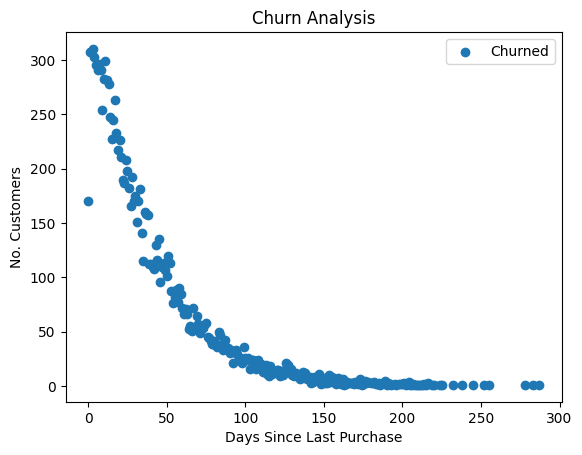

In [46]:
plt.scatter(churn_group_churned['Days_Since_Last_Purchase'], churn_group_churned['count'], label='Churned')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('No. Customers')
plt.title('Churn Analysis')
plt.legend()
plt.show()

In [47]:
# The original churn_dataset has Days_Since_Last_Purchase 
churn_dataset['Days_Since_Last_Purchase'].sort_values(ascending=True).unique()[:5]

array([0., 1., 2., 3., 4.])

In [48]:
# Calculate Churn Rate

___

# CatBoost <a id='catboost'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>


In [49]:
y = churn_df['Churned']
X = churn_df.drop('Churned', axis=1)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model_cb1 = CatBoostClassifier(iterations=100, learning_rate=0.1, verbose=0)
model_cb1.fit(X_train, y_train)

# Model predictions
y_proba = model_cb1.predict_proba(X_test)[:, 1]

Assigning/determining risk tiers

In [50]:
low_risk_thresholds = [0.3, 0.325, 0.35, 0.375, 0.4, 0.425, 0.45, 0.475, 0.5]
med_risk_thresholds = [0.4, 0.45, 0.5, 0.525, 0.55, 0.575, 0.6, 0.625, 0.65]
low_ta, med_ta = determine_best_risk_thresholds(y_proba, y_test, low_risk_thresholds, med_risk_thresholds)

Best Results
----------------------------------------------
Low threshold: 0.5
Medium threshold: 0.6
Accuracy: 0.764
                Low      High
                             
Precision  0.814628  0.794931
Recall     0.926367  0.360627
F1 Score   0.866912  0.496165


## Hyperparameter Tuning

In [51]:
y = churn_df['Churned']
X = churn_df.drop('Churned', axis=1)

# Train test split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ready model
model_cb2 = CatBoostClassifier(logging_level='Silent')

### Depth <a id='cb_ht_depth'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

In [52]:
param_grid = {'depth': [3,4,5,6]}

grid_search_result = model_cb2.grid_search(
    param_grid,
    X=X_train, y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result['params'] )

Best parameters found: {'depth': 5}


### Number of Iterations <a id='cb_ht_iterations'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

In [53]:
model_cb3 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
}

grid_search_result2 = model_cb3.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result2['params'] )

Best parameters found: {'depth': 5, 'iterations': 600}


In [54]:
model_cb4 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [580, 585, 590, 595, 600, 605, 610, 615, 620]
}

grid_search_result3 = model_cb4.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result3['params'] )

Best parameters found: {'depth': 5, 'iterations': 580}


In [55]:
model_cb5 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [550, 565, 560, 565, 570, 575, 580]
}

grid_search_result4 = model_cb5.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result4['params'] )

Best parameters found: {'depth': 5, 'iterations': 565}


In [56]:
model_cb6 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [561, 562, 563, 564, 565, 566, 567, 568, 569]
}

grid_search_result5 = model_cb6.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result5['params'] )

Best parameters found: {'depth': 5, 'iterations': 561}


In [57]:
model_cb7 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [551, 552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562]
}

grid_search_result6 = model_cb7.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result6['params'] )

Best parameters found: {'depth': 5, 'iterations': 554}


### Learning Rate <a id='cb_ht_lr'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

In [58]:
model_cb8 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
}

grid_search_result7 = model_cb8.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result7['params'] )

Best parameters found: {'depth': 5, 'learning_rate': 0.2, 'iterations': 554}


In [59]:
model_cb9 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.125, 0.15, 0.175, 0.2, 0.225, 0.25]
}

grid_search_result8 = model_cb9.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result8['params'] )

Best parameters found: {'depth': 5, 'learning_rate': 0.15, 'iterations': 554}


### Early Stopping Rounds <a id='cb_ht_es'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

In [60]:
model_cb10 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.15],
    'early_stopping_rounds': [False, 2, 5, 7, 10, 12, 15]
}

grid_search_result9 = model_cb10.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result9['params'] )

Best parameters found: {'depth': 5, 'od_wait': 10, 'learning_rate': 0.15, 'iterations': 554}


### Grow Policy <a id='cb_ht_gp'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

In [61]:
model_cb11 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.15],
    'early_stopping_rounds': [10],
    'grow_policy': ['SymmetricTree','Depthwise','Lossguide']
}

grid_search_result10 = model_cb11.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result10['params'] )

Best parameters found: {'grow_policy': 'SymmetricTree', 'depth': 5, 'od_wait': 10, 'learning_rate': 0.15, 'iterations': 554}


### Regularisation <a id='cb_ht_re'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

**L2 Regularisation, Random Strength and Bagging Temperature**

In [62]:
model_cb12 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.15],
    'early_stopping_rounds': [10],
    'grow_policy': ['SymmetricTree'],
    'l2_leaf_reg': [0, 1, 3, 5, 7, 9, 10, 12, 15],
    'random_strength': [0, 0.5, 1, 1.5, 2],
    'bagging_temperature': [0, 0.1, 0.5, 0.7, 1]
}

grid_search_result11 = model_cb12.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result11['params'] )

Best parameters found: {'random_strength': 1, 'od_wait': 10, 'iterations': 554, 'bagging_temperature': 0, 'l2_leaf_reg': 10, 'grow_policy': 'SymmetricTree', 'depth': 5, 'learning_rate': 0.15}


**Final Grid Search**

Double checking learning rate, iterations, depth, early stopping rounds, grow policy, bagging temperature and regularisation.

From the above, we expect the following 'best results':
- Depth: 5
- Number of Iterations: 554
- Learning Rate: 0.15
- Early Stopping Rounds: 10
- Grow Policy: SymmetricTree
- Regularisation: l2_leaf_reg = 10, random_strength = 1, bagging_temperature = 0

In [63]:
model_cb13 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'learning_rate': [0.15, 0.2],
    'iterations': [554, 558, 561],
    'depth': [4, 5, 6],
    'early_stopping_rounds': [False, 10],
    'l2_leaf_reg': [0, 5, 10],
    'grow_policy': ['SymmetricTree','Depthwise','Lossguide'],
    'random_strength': [0, 1],
    'bagging_temperature': [0, 1],
    'logging_level': ['Silent']
}

grid_search_result12 = model_cb13.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result12['params'] )

Best parameters found: {'random_strength': 0, 'od_wait': 10, 'iterations': 554, 'logging_level': 'Silent', 'bagging_temperature': 0, 'l2_leaf_reg': 5, 'grow_policy': 'SymmetricTree', 'depth': 4, 'learning_rate': 0.15}


Ha, nope - I was close, though. A couple of them were right.

### Checking the current 'best performer'

In [64]:
model_cb14 = CatBoostClassifier(logging_level='Silent',
    iterations = 554,
    learning_rate = 0.15,
    depth = 4,
    grow_policy = 'SymmetricTree',
    bagging_temperature = 0,
    random_strength = 0,
    early_stopping_rounds = 10)

model_cb14.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=False
)

y_pred_14 = model_cb14.predict(X_test)

#### AUC-ROC

In [65]:
y_pred_proba14 = model_cb14.predict_proba(X_test)[:, 1]
auc_score_cb14 = roc_auc_score(y_test, y_pred_proba14)
print(f"CatBoost AUC-ROC: {auc_score_cb14:.4f}")

CatBoost AUC-ROC: 0.8039


<a id='Fig5'>Fig 5</a>: ROC Curve for CatBoost Model 14 <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

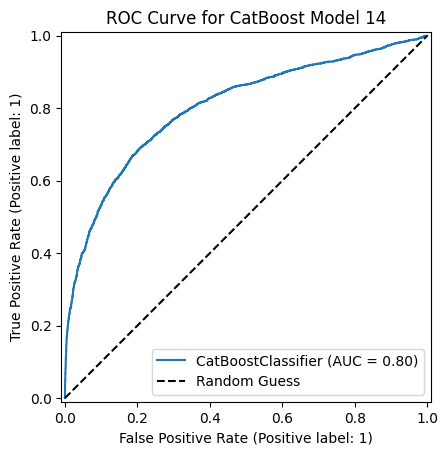

In [66]:
RocCurveDisplay.from_estimator(model_cb14, X_test, y_test)
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title('ROC Curve for CatBoost Model 14'); plt.legend(); plt.show()

---
# Random Forest <a id='randomforest'> </a>

<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2b))</span>

In [67]:
y = churn_df['Churned']
X = churn_df.drop('Churned', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Impute missing values based on median - Fitted then applied based on training data, then applied to test data. 

In [68]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [69]:
model = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

Thresholds suggested were at maximum, expanded scope and they settled

In [70]:
low_risk_thresholds = [0.3, 0.325, 0.35, 0.375, 0.4, 0.425, 0.45, 0.475, 0.5, 0.525, 0.5]
med_risk_thresholds = [0.4, 0.45, 0.5, 0.525, 0.55, 0.575, 0.6, 0.625, 0.65, 0.675, 0.7]

In [71]:
report = classification_report(y_test, y_pred)
print(report)
low_t, med_t = determine_best_risk_thresholds(y_proba, y_test, low_risk_thresholds, med_risk_thresholds)
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86      7130
           1       0.70      0.48      0.57      2870

    accuracy                           0.79     10000
   macro avg       0.76      0.70      0.71     10000
weighted avg       0.78      0.79      0.78     10000

Best Results
----------------------------------------------
Low threshold: 0.525
Medium threshold: 0.675
Accuracy: 0.7399
                Low      High
                             
Precision  0.807052  0.842746
Recall     0.930996  0.265157
F1 Score   0.864604  0.403393
[[6546  584]
 [1506 1364]]


In [72]:
risk_counts = Counter(assign_risk_tier(p, low_t, med_t) for p in y_proba)

print("Low:", risk_counts['Low']) 
print("Medium:", risk_counts['Med']) 
print("High:", risk_counts['High'])

Low: 8225
Medium: 872
High: 903


## Hyperparameter Tuning

In [73]:
model_rf1 = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [300, 600],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

grid_search_rf = GridSearchCV(
    estimator=model_rf1,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)
print(grid_search_rf.best_params_)
print(grid_search_rf.best_score_)
model_rf_best = grid_search_rf.best_estimator_

Fitting 3 folds for each of 96 candidates, totalling 288 fits
{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 600}
0.6215086849518671


In [74]:
y_pred2 = grid_search_rf.predict(X_test)
y_proba2 = grid_search_rf.predict_proba(X_test)[:, 1]
report2 = classification_report(y_test, y_pred2)
print(report2)
low_t, med_t = determine_best_risk_thresholds(y_proba2, y_test, low_risk_thresholds, med_risk_thresholds)
print(confusion_matrix(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.86      0.79      0.83      7130
           1       0.57      0.69      0.62      2870

    accuracy                           0.76     10000
   macro avg       0.72      0.74      0.72     10000
weighted avg       0.78      0.76      0.77     10000

Best Results
----------------------------------------------
Low threshold: 0.525
Medium threshold: 0.675
Accuracy: 0.7107
                Low      High
                             
Precision  0.855226  0.720751
Recall     0.813604  0.455052
F1 Score   0.833896  0.557881
[[5641 1489]
 [ 903 1967]]


In [75]:
risk_counts = Counter(assign_risk_tier(p, low_t, med_t) for p in y_proba2)

print("Low:", risk_counts['Low']) 
print("Medium:", risk_counts['Med']) 
print("High:", risk_counts['High'])

Low: 6783
Medium: 1405
High: 1812


The second model has much better recall, catching 69% of the class 1 cases (Pers at risk of churn) - but this is at a cost of many more false positives. For the assignment, this isn't a bad thing as automated emails to low risk customers should have low tradeoff comparative to missing incentives for high risk customers. This is further shown in the recall for the high risk customers shifting from 38-59, higher than the initial catboost model at 36 for high risk recalls. 

In [76]:
X3 = churn_df.drop(['Churned', 'Login_Frequency', 'Mobile_App_Usage', 'Wishlist_Items', 'Pages_Per_Session'], axis=1)

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y, test_size=0.2, random_state=42)

X_train3 = imputer.fit_transform(X_train3)
X_test3 = imputer.transform(X_test3)

In [77]:
X3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Session_Duration_Avg   46601 non-null  float64
 1   Cart_Abandonment_Rate  50000 non-null  float64
 2   Total_Purchases        50000 non-null  float64
 3   Email_Open_Rate        47472 non-null  float64
 4   Lifetime_Value         50000 non-null  float64
 5   Credit_Balance         44500 non-null  float64
dtypes: float64(6)
memory usage: 2.3 MB


In [78]:
model = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

model.fit(X_train3, y_train3)

y_proba3 = model.predict_proba(X_test3)[:, 1]
y_pred3 = model.predict(X_test3)

In [79]:
report3 = classification_report(y_test3, y_pred3)
print(report3)
low_t3, med_t3 = determine_best_risk_thresholds(y_proba3, y_test3, low_risk_thresholds, med_risk_thresholds)
print(confusion_matrix(y_test3, y_pred3))

              precision    recall  f1-score   support

           0       0.81      0.91      0.86      7130
           1       0.68      0.46      0.55      2870

    accuracy                           0.78     10000
   macro avg       0.74      0.69      0.70     10000
weighted avg       0.77      0.78      0.77     10000

Best Results
----------------------------------------------
Low threshold: 0.525
Medium threshold: 0.675
Accuracy: 0.7352
                Low      High
                             
Precision  0.800534  0.790407
Recall     0.924825  0.264111
F1 Score   0.858203  0.395926
[[6513  617]
 [1557 1313]]


<a id='Fig14'>Fig 14</a>: Confusion Matrix for Random Forest<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2b))</span>

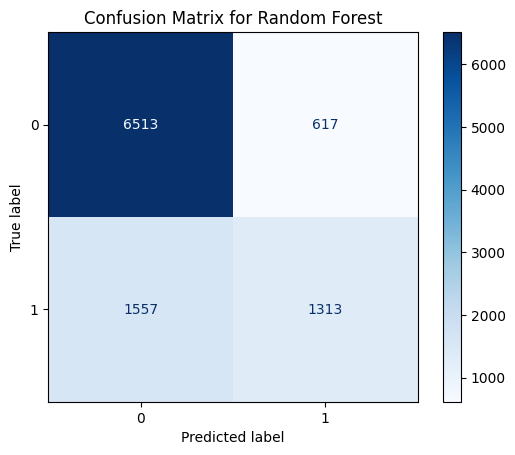

In [80]:
cm = confusion_matrix(y_test3, y_pred3, labels=model.classes_)
cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
cm_disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Random Forest")
plt.show()

Based on this, more features lowers recall. Best design (For recall) is currently just the optimized forest with all features.

---

# XGBoost <a id='xgboost'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2c))</span>

In [81]:
xgb_model = XGBClassifier(random_state=42)

xgb_model.fit(X_train, y_train)

y_proba4 = xgb_model.predict_proba(X_test)[:, 1]
y_pred4 = xgb_model.predict(X_test)

In [82]:
report4 = classification_report(y_test, y_pred4)
print(report4)
low_t4, med_t4 = determine_best_risk_thresholds(y_proba4, y_test, low_risk_thresholds, med_risk_thresholds)
print(confusion_matrix(y_test, y_pred4))

              precision    recall  f1-score   support

           0       0.81      0.91      0.86      7130
           1       0.68      0.47      0.56      2870

    accuracy                           0.78     10000
   macro avg       0.74      0.69      0.71     10000
weighted avg       0.77      0.78      0.77     10000

Best Results
----------------------------------------------
Low threshold: 0.525
Medium threshold: 0.675
Accuracy: 0.7445
                Low      High
                             
Precision  0.805297  0.783036
Recall     0.921178  0.305575
F1 Score   0.859348  0.439599
[[6482  648]
 [1508 1362]]


## Hyperparameter Tuning

In [83]:
param_grid = {
    'n_estimators': [100, 300, 600],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 5]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train, y_train)
print(grid_search_xgb.best_params_)
print(grid_search_xgb.best_score_)
model_xgb_best = grid_search_xgb.best_estimator_

Fitting 3 folds for each of 216 candidates, totalling 648 fits
{'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 0.8}
0.564010515510966


In [84]:
y_pred5 = model_xgb_best.predict(X_test)
y_proba5 = model_xgb_best.predict_proba(X_test)[:, 1]
report5 = classification_report(y_test, y_pred5)
print(report5)
low_t5, med_t5 = determine_best_risk_thresholds(y_proba5, y_test, low_risk_thresholds, med_risk_thresholds)
print(confusion_matrix(y_test, y_pred5))

              precision    recall  f1-score   support

           0       0.81      0.92      0.87      7130
           1       0.71      0.48      0.57      2870

    accuracy                           0.79     10000
   macro avg       0.76      0.70      0.72     10000
weighted avg       0.79      0.79      0.78     10000

Best Results
----------------------------------------------
Low threshold: 0.525
Medium threshold: 0.675
Accuracy: 0.7448
                Low      High
                             
Precision  0.807636  0.850488
Recall     0.934502  0.273519
F1 Score   0.866450  0.413920
[[6579  551]
 [1500 1370]]


Testing to see how low the threshold needs to be before it begins to perform similarly to the Random Forest. 

In [85]:
for threshold in [0.2, 0.3, 0.4, 0.5]:
    y_pred = (y_proba5 >= threshold).astype(int)

    print(
        f"Threshold {threshold}:",
        f"Precision={precision_score(y_test, y_pred):.3f}",
        f"Recall={recall_score(y_test, y_pred):.3f}",
        f"F1={f1_score(y_test, y_pred):.3f}"
    )

Threshold 0.2: Precision=0.473 Recall=0.806 F1=0.596
Threshold 0.3: Precision=0.549 Recall=0.709 F1=0.619
Threshold 0.4: Precision=0.623 Recall=0.595 F1=0.609
Threshold 0.5: Precision=0.713 Recall=0.477 F1=0.572


---

# LightGBM <a id='lightgbm'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2d))</span>

In [86]:
lgb_model = LGBMClassifier(random_state=42)

lgb_model.fit(X_train, y_train)

y_proba5 = lgb_model.predict_proba(X_test)[:, 1]
y_pred5 = lgb_model.predict(X_test)

[LightGBM] [Info] Number of positive: 11580, number of negative: 28420
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001643 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1900
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.289500 -> initscore=-0.897814
[LightGBM] [Info] Start training from score -0.897814


In [87]:
report5 = classification_report(y_test, y_pred5)
print(report5)
low_t5, med_t5 = determine_best_risk_thresholds(y_proba5, y_test, low_risk_thresholds, med_risk_thresholds)
print(confusion_matrix(y_test, y_pred5))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86      7130
           1       0.70      0.47      0.57      2870

    accuracy                           0.79     10000
   macro avg       0.76      0.70      0.71     10000
weighted avg       0.78      0.79      0.78     10000

Best Results
----------------------------------------------
Low threshold: 0.525
Medium threshold: 0.675
Accuracy: 0.7465
                Low      High
                             
Precision  0.805677  0.830474
Recall     0.931557  0.286760
F1 Score   0.864056  0.426314
[[6561  569]
 [1512 1358]]


## Hyperparameter Tuning

In [88]:
param_grid = {
    'n_estimators': [100, 300, 600],
    'max_depth': [-1, 3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search_lgb = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_lgb.fit(X_train, y_train)
print(grid_search_lgb.best_params_)
print(grid_search_lgb.best_score_)
model_lgb_best = grid_search_lgb.best_estimator_

Fitting 3 folds for each of 432 candidates, totalling 1296 fits
[LightGBM] [Info] Number of positive: 11580, number of negative: 28420
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002203 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1900
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.289500 -> initscore=-0.897814
[LightGBM] [Info] Start training from score -0.897814
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [89]:
y_pred6 = grid_search_lgb.predict(X_test)
y_proba6 = grid_search_lgb.predict_proba(X_test)[:, 1]
report6 = classification_report(y_test, y_pred6)
print(report6)
low_t6, med_t6 = determine_best_risk_thresholds(y_proba6, y_test, low_risk_thresholds, med_risk_thresholds)
print(confusion_matrix(y_test, y_pred6))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86      7130
           1       0.71      0.47      0.57      2870

    accuracy                           0.79     10000
   macro avg       0.76      0.70      0.72     10000
weighted avg       0.78      0.79      0.78     10000

Best Results
----------------------------------------------
Low threshold: 0.525
Medium threshold: 0.675
Accuracy: 0.7456
                Low      High
                             
Precision  0.806843  0.838710
Recall     0.932679  0.280836
F1 Score   0.865209  0.420778
[[6578  552]
 [1511 1359]]


In [90]:
for threshold in [0.2, 0.3, 0.4, 0.5]:
    y_pred = (y_proba6 >= threshold).astype(int)

    print(
        f"Threshold {threshold}:",
        f"Precision={precision_score(y_test, y_pred):.3f}",
        f"Recall={recall_score(y_test, y_pred):.3f}",
        f"F1={f1_score(y_test, y_pred):.3f}"
    )

Threshold 0.2: Precision=0.477 Recall=0.802 F1=0.598
Threshold 0.3: Precision=0.553 Recall=0.714 F1=0.623
Threshold 0.4: Precision=0.634 Recall=0.595 F1=0.614
Threshold 0.5: Precision=0.711 Recall=0.474 F1=0.569


Quick comparison against CatBoost Model

In [91]:
model_cb14 = CatBoostClassifier(logging_level='Silent',
    iterations = 554,
    learning_rate = 0.15,
    depth = 4,
    grow_policy = 'SymmetricTree',
    bagging_temperature = 0,
    random_strength = 0,
    early_stopping_rounds = 10)

model_cb14.fit(X_train, y_train)

y_proba7 = model_cb14.predict_proba(X_test)[:, 1]
y_pred7 = model_cb14.predict(X_test)

In [92]:
report7 = classification_report(y_test, y_pred7)
print(report7)
low_t7, med_t7 = determine_best_risk_thresholds(y_proba7, y_test, low_risk_thresholds, med_risk_thresholds)
print(confusion_matrix(y_test, y_pred7))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86      7130
           1       0.70      0.48      0.57      2870

    accuracy                           0.79     10000
   macro avg       0.76      0.70      0.72     10000
weighted avg       0.78      0.79      0.78     10000

Best Results
----------------------------------------------
Low threshold: 0.525
Medium threshold: 0.675
Accuracy: 0.7453
                Low      High
                             
Precision  0.806746  0.828829
Recall     0.929173  0.288502
F1 Score   0.863642  0.428018
[[6533  597]
 [1492 1378]]


Back to the random forest to tune it further

---

# Revisiting Random Forest <a id='randomforest2'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2e))</span>

In [93]:
model_rf2 = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [600, 700, 800],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

grid_search_rf2 = GridSearchCV(
    estimator=model_rf2,
    param_grid=param_grid,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search_rf2.fit(X_train, y_train)
print(grid_search_rf2.best_params_)
print(grid_search_rf2.best_score_)
model_rf_best2 = grid_search_rf2.best_estimator_

Fitting 3 folds for each of 144 candidates, totalling 432 fits
{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 800}
0.7193436960276339


In [94]:
y_pred8 = grid_search_rf2.predict(X_test)
y_proba8 = grid_search_rf2.predict_proba(X_test)[:, 1]
report8 = classification_report(y_test, y_pred8)
print(report8)
low_t8, med_t8 = determine_best_risk_thresholds(y_proba8, y_test, low_risk_thresholds, med_risk_thresholds)
print(confusion_matrix(y_test, y_pred8))

              precision    recall  f1-score   support

           0       0.87      0.75      0.81      7130
           1       0.54      0.73      0.62      2870

    accuracy                           0.74     10000
   macro avg       0.71      0.74      0.71     10000
weighted avg       0.78      0.74      0.75     10000

Best Results
----------------------------------------------
Low threshold: 0.525
Medium threshold: 0.675
Accuracy: 0.6604
                Low      High
                             
Precision  0.864357  0.761538
Recall     0.787377  0.344948
F1 Score   0.824073  0.474820
[[5345 1785]
 [ 787 2083]]


Currently against a baseline of 'Email everyone' (10000 emails & offers) - The company is looking at around 4000 emails, with ~55% of these successfully capturing ~75% of customers at risk of churning/leaving. 

In [95]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Login_Frequency        50000 non-null  float64
 1   Session_Duration_Avg   46601 non-null  float64
 2   Pages_Per_Session      47000 non-null  float64
 3   Cart_Abandonment_Rate  50000 non-null  float64
 4   Wishlist_Items         46000 non-null  float64
 5   Total_Purchases        50000 non-null  float64
 6   Email_Open_Rate        47472 non-null  float64
 7   Mobile_App_Usage       45000 non-null  float64
 8   Lifetime_Value         50000 non-null  float64
 9   Credit_Balance         44500 non-null  float64
 10  Churned                50000 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 4.2 MB


In [96]:
X4 = churn_df[['Lifetime_Value', 'Cart_Abandonment_Rate', 'Email_Open_Rate', 'Total_Purchases']]

X_train4, X_test4, y_train4, y_test4 = train_test_split(X4, y, test_size=0.2, random_state=42)

X_train4 = imputer.fit_transform(X_train4)
X_test4 = imputer.transform(X_test4)

Fitting 3 folds for each of 144 candidates, totalling 432 fits
{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 800}
0.7193436960276339

In [97]:
model_rf3 = RandomForestClassifier(
    random_state = 42,
    class_weight = 'balanced', 
    max_depth = 5, 
    max_features = 'sqrt', 
    min_samples_leaf = 1, 
    min_samples_split = 2, 
    n_estimators = 800
)

model_rf3.fit(X_train4, y_train4)

y_pred9 = model_rf3.predict(X_test4)
y_proba9 = model_rf3.predict_proba(X_test4)[:, 1]
report9 = classification_report(y_test4, y_pred9)
print(report9)
low_t9, med_t9 = determine_best_risk_thresholds(y_proba9, y_test4, low_risk_thresholds, med_risk_thresholds)
print(confusion_matrix(y_test4, y_pred9))

              precision    recall  f1-score   support

           0       0.87      0.74      0.80      7130
           1       0.52      0.72      0.61      2870

    accuracy                           0.73     10000
   macro avg       0.70      0.73      0.70     10000
weighted avg       0.77      0.73      0.74     10000

Best Results
----------------------------------------------
Low threshold: 0.525
Medium threshold: 0.675
Accuracy: 0.6838
                Low      High
                             
Precision  0.859089  0.685439
Recall     0.769565  0.470732
F1 Score   0.811867  0.558149
[[5245 1885]
 [ 801 2069]]


---

# Stacking <a id='stacking'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2e))</span>

Let's see if we can eke out a slightly better performance by stacking models

In [98]:
churn_df = pd.read_csv('datasets/churn_data_ready.csv') # Revert the data back to it's initial encoded state, complete with all features
y = churn_df['Churned']
X = churn_df.drop('Churned', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

feature_list1 = ['Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Email_Open_Rate', 'Mobile_App_Usage', 'Lifetime_Value', 'Credit_Balance']
feature_list2 = ['Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Total_Purchases', 'Email_Open_Rate', 'Lifetime_Value',
       'Credit_Balance']
feature_list3 = ['Lifetime_Value', 'Cart_Abandonment_Rate', 'Email_Open_Rate', 'Total_Purchases']

In [99]:
base_estimators1 = [ 
        ('rf', RandomForestClassifier(random_state = 42,
                                  class_weight = 'balanced',
                                  max_depth = 5,
                                  max_features = 'sqrt',
                                  min_samples_leaf = 1,
                                  min_samples_split = 2,
                                  n_estimators = 800)),
        ('xgb', XGBClassifier(random_state = 42,
                                n_estimators=100,
                                learning_rate=0.2,
                                max_depth=3,
                                min_child_weight=5,
                                subsample=0.8,
                                colsample_bytree=0.8))
]

base_estimators2 = [ 
        ('rf', RandomForestClassifier(random_state = 42,
                                  class_weight = 'balanced',
                                  max_depth = 5,
                                  max_features = 'sqrt',
                                  min_samples_leaf = 1,
                                  min_samples_split = 2,
                                  n_estimators = 800)),
        ('cat', CatBoostClassifier(random_state = 42,
                                   logging_level='Silent',
                                   iterations = 554,
                                   learning_rate = 0.15,
                                   depth = 4,
                                   grow_policy = 'SymmetricTree',
                                   bagging_temperature = 0,
                                   random_strength = 0,
                                   early_stopping_rounds = 10))
]

base_estimators3 = [ 
        ('rf', RandomForestClassifier(random_state = 42,
                                  class_weight = 'balanced',
                                  max_depth = 5,
                                  max_features = 'sqrt',
                                  min_samples_leaf = 1,
                                  min_samples_split = 2,
                                  n_estimators = 800)),
        ('lgbm', LGBMClassifier(random_state = 42,
                                    colsample_bytree=1.0,
                                    learning_rate=0.05,
                                    max_depth=5,
                                    n_estimators=300,
                                    num_leaves=15,
                                    subsample=0.8,
                                    verbosity=-1,
                                    logging_level='Silent'))
]

base_estimators4 = [ 
        ('rf', RandomForestClassifier(random_state = 42,
                                  class_weight = 'balanced',
                                  max_depth = 5,
                                  max_features = 'sqrt',
                                  min_samples_leaf = 1,
                                  min_samples_split = 2,
                                  n_estimators = 800)),
        ('cat', CatBoostClassifier(random_state = 42,
                                        logging_level='Silent',
                                        iterations = 554,
                                        learning_rate = 0.15,
                                        depth = 4,
                                        grow_policy = 'SymmetricTree',
                                        bagging_temperature = 0,
                                        random_strength = 0,
                                        early_stopping_rounds = 10)),
        ('lgbm', LGBMClassifier(random_state = 42,
                                    colsample_bytree=1.0,
                                    learning_rate=0.05,
                                    max_depth=5,
                                    n_estimators=300,
                                    num_leaves=15,
                                    subsample=0.8,
                                    verbosity=-1,
                                    logging_level='Silent'))
]

base_estimators5 = [ 
        ('rf', RandomForestClassifier(random_state = 42,
                                  class_weight = 'balanced',
                                  max_depth = 5,
                                  max_features = 'sqrt',
                                  min_samples_leaf = 1,
                                  min_samples_split = 2,
                                  n_estimators = 800)),
        ('cat', CatBoostClassifier(random_state = 42,
                                        logging_level='Silent',
                                        iterations = 554,
                                        learning_rate = 0.15,
                                        depth = 4,
                                        grow_policy = 'SymmetricTree',
                                        bagging_temperature = 0,
                                        random_strength = 0,
                                        early_stopping_rounds = 10)),
        ('xgb', XGBClassifier(random_state = 42,
                                n_estimators=100,
                                learning_rate=0.2,
                                max_depth=3,
                                min_child_weight=5,
                                subsample=0.8,
                                colsample_bytree=0.8))
]

base_estimators6 = [ 
        ('rf', RandomForestClassifier(random_state = 42,
                                  class_weight = 'balanced',
                                  max_depth = 5,
                                  max_features = 'sqrt',
                                  min_samples_leaf = 1,
                                  min_samples_split = 2,
                                  n_estimators = 800)),
        ('lgbm', LGBMClassifier(random_state = 42,
                                    colsample_bytree=1.0,
                                    learning_rate=0.05,
                                    max_depth=5,
                                    n_estimators=300,
                                    num_leaves=15,
                                    subsample=0.8,
                                    verbosity=-1,
                                    logging_level='Silent')),
        ('xgb', XGBClassifier(random_state = 42,
                                n_estimators=100,
                                learning_rate=0.2,
                                max_depth=3,
                                min_child_weight=5,
                                subsample=0.8,
                                colsample_bytree=0.8))
]

base_estimators7 = [ 
        ('cat', CatBoostClassifier(random_state = 42,
                                                logging_level='Silent',
                                                iterations = 554,
                                                learning_rate = 0.15,
                                                depth = 4,
                                                grow_policy = 'SymmetricTree',
                                                bagging_temperature = 0,
                                                random_strength = 0,
                                                early_stopping_rounds = 10))
]

base_estimators8 = [
    ('rf', RandomForestClassifier(random_state = 42,class_weight = 'balanced',max_depth = 5,n_estimators = 800))
]

meta_estimator1 = LogisticRegression()
meta_estimator2 = RidgeClassifier(alpha=1.0, random_state=42)
meta_estimator3 = RandomForestClassifier(random_state = 42,class_weight = 'balanced',max_depth = 5,n_estimators = 800)

In [100]:
stacking_1 = {'Model': 'Stacking 1', 'Base Models': 'RF + XGBoost', 'Meta Estimator': 'Logistic Regression', 'Features': len(feature_list1)}
stacking_model1 = StackingClassifier(estimators=base_estimators1, final_estimator=meta_estimator1, cv=5)
stacking_model1.fit(X_train, y_train)
y_pred10 = stacking_model1.predict(X_test)

stacking_2 = {'Model': 'Stacking 2', 'Base Models': 'RF + CatBoost', 'Meta Estimator': 'Logistic Regression', 'Features': len(feature_list1)}
stacking_model2 = StackingClassifier(estimators=base_estimators2, final_estimator=meta_estimator1, cv=5)
stacking_model2.fit(X_train, y_train)
y_pred11 = stacking_model2.predict(X_test)

stacking_3 = {'Model': 'Stacking 3', 'Base Models': 'RF + LightGBM', 'Meta Estimator': 'Logistic Regression', 'Features': len(feature_list1)}
stacking_model3 = StackingClassifier(estimators=base_estimators3, final_estimator=meta_estimator1, cv=5)
stacking_model3.fit(X_train, y_train)
y_pred12 = stacking_model3.predict(X_test)

stacking_4 = {'Model': 'Stacking 4', 'Base Models': 'RF + CatBoost + LightGBM', 'Meta Estimator': 'Logistic Regression', 'Features': len(feature_list1)}
stacking_model4 = StackingClassifier(estimators=base_estimators4, final_estimator=meta_estimator1, cv=5)
stacking_model4.fit(X_train, y_train)
y_pred13 = stacking_model4.predict(X_test)

stacking_5 = {'Model': 'Stacking 5', 'Base Models': 'RF + CatBoost + XGBoost', 'Meta Estimator': 'Logistic Regression', 'Features': len(feature_list1)}
stacking_model5 = StackingClassifier(estimators=base_estimators5, final_estimator=meta_estimator1, cv=5)
stacking_model5.fit(X_train, y_train)
y_pred14 = stacking_model5.predict(X_test)

stacking_6 = {'Model': 'Stacking 6', 'Base Models': 'RF + LightGBM + XGBoost', 'Meta Estimator': 'Logistic Regression', 'Features': len(feature_list1)}
stacking_model6 = StackingClassifier(estimators=base_estimators6, final_estimator=meta_estimator1, cv=5)
stacking_model6.fit(X_train, y_train)
y_pred15 = stacking_model6.predict(X_test)

In [101]:
X2 = churn_df[feature_list2] # Testing out a smaller number of features
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)

X3 = churn_df[feature_list3] # Testing out an even smaller number of features
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y, test_size=0.2, random_state=42)

In [102]:
stacking_7 = {'Model': 'Stacking 7', 'Base Models': 'CatBoost', 'Meta Estimator': 'Random Forest', 'Features': len(feature_list1)}
stacking_model7 = StackingClassifier(estimators=base_estimators7, final_estimator=meta_estimator3, cv=5)
stacking_model7.fit(X_train, y_train)
y_pred16 = stacking_model7.predict(X_test)

stacking_8 = {'Model': 'Stacking 8', 'Base Models': 'Random Forest', 'Meta Estimator': 'Ridge Classifier', 'Features': len(feature_list1)}
stacking_model8 = StackingClassifier(estimators=base_estimators8, final_estimator=meta_estimator2, cv=5)
stacking_model8.fit(X_train, y_train)
y_pred17 = stacking_model8.predict(X_test)

stacking_9 = {'Model': 'Stacking 9', 'Base Models': 'Random Forest', 'Meta Estimator': 'Logistic Regression', 'Features': len(feature_list1)}
stacking_model9 = StackingClassifier(estimators=base_estimators8, final_estimator=meta_estimator1, cv=5)
stacking_model9.fit(X_train, y_train)
y_pred18 = stacking_model9.predict(X_test)

stacking_10 = {'Model': 'Stacking 10', 'Base Models': 'RF + CatBoost', 'Meta Estimator': 'Random Forest', 'Features': len(feature_list1)}
stacking_model10 = StackingClassifier(estimators=base_estimators2, final_estimator=meta_estimator3, cv=5)
stacking_model10.fit(X_train, y_train)
y_pred19 = stacking_model10.predict(X_test)

stacking_11 = {'Model': 'Stacking 11', 'Base Models': 'RF + CatBoost (Threshold = 0.7)', 'Meta Estimator': 'Random Forest', 'Features': len(feature_list1)}
y_prob20 = stacking_model10.predict_proba(X_test)[:,1]
y_pred20 = (y_prob20 >= 0.7).astype(int)

stacking_12 = {'Model': 'Stacking 12', 'Base Models': 'RF + CatBoost (Threshold = 0.6)', 'Meta Estimator': 'Random Forest', 'Features': len(feature_list1)}
y_prob21 = stacking_model10.predict_proba(X_test)[:,1]
y_pred21 = (y_prob21 >= 0.6).astype(int)

In [103]:
stacking_13 = {'Model': 'Stacking 13', 'Base Models': 'RF + CatBoost', 'Meta Estimator': 'Random Forest', 'Features': len(feature_list2)}
stacking_model13 = StackingClassifier(estimators=base_estimators2, final_estimator=meta_estimator3, cv=5)
stacking_model13.fit(X2_train, y2_train)
y_pred22 = stacking_model13.predict(X2_test)

stacking_14 = {'Model': 'Stacking 14', 'Base Models': 'RF + CatBoost', 'Meta Estimator': 'Random Forest', 'Features': len(feature_list3)}
stacking_model14 = StackingClassifier(estimators=base_estimators2, final_estimator=meta_estimator3, cv=5)
stacking_model14.fit(X3_train, y3_train)
y_pred23 = stacking_model14.predict(X3_test)

In [105]:
stacking_models = pd.DataFrame([stacking_1, stacking_2, stacking_3, stacking_4, stacking_5, stacking_6, stacking_7, stacking_8, stacking_9, 
                                stacking_10, stacking_11, stacking_12, stacking_13, stacking_14])
stacking_metrics = pd.DataFrame({'Accuracy': [accuracy_score(y_test, y_pred10),accuracy_score(y_test, y_pred11),
                                              accuracy_score(y_test, y_pred12),accuracy_score(y_test, y_pred13),
                                              accuracy_score(y_test, y_pred14),accuracy_score(y_test, y_pred15),
                                              accuracy_score(y2_test, y_pred16),accuracy_score(y2_test, y_pred17),
                                              accuracy_score(y2_test, y_pred18),accuracy_score(y2_test, y_pred19),
                                              accuracy_score(y2_test, y_pred20),accuracy_score(y2_test, y_pred21),
                                              accuracy_score(y2_test, y_pred22), accuracy_score(y2_test, y_pred23)],
                    'Precision': [precision_score(y_test, y_pred10), precision_score(y_test, y_pred11), 
                                  precision_score(y_test, y_pred12), precision_score(y_test, y_pred13), 
                                  precision_score(y_test, y_pred14), precision_score(y_test, y_pred15),
                                  precision_score(y2_test, y_pred16), precision_score(y2_test, y_pred17),
                                  precision_score(y2_test, y_pred18), precision_score(y2_test, y_pred19),
                                  precision_score(y2_test, y_pred20), precision_score(y2_test, y_pred21),
                                  precision_score(y2_test, y_pred22), precision_score(y2_test, y_pred23)],
                    'Recall': [recall_score(y_test, y_pred10), recall_score(y_test, y_pred11), 
                               recall_score(y_test, y_pred12), recall_score(y_test, y_pred13), 
                               recall_score(y_test, y_pred14), recall_score(y_test, y_pred15),
                               recall_score(y2_test, y_pred16), recall_score(y2_test, y_pred17),
                               recall_score(y2_test, y_pred18), recall_score(y2_test, y_pred19),
                               recall_score(y2_test, y_pred20), recall_score(y2_test, y_pred21),
                               recall_score(y2_test, y_pred22), recall_score(y2_test, y_pred23)],
                    'F1-Score': [f1_score(y_test, y_pred10), f1_score(y_test, y_pred11), 
                                 f1_score(y_test, y_pred12), f1_score(y_test, y_pred13), 
                                 f1_score(y_test, y_pred14), f1_score(y_test, y_pred15),
                                 f1_score(y2_test, y_pred16), f1_score(y2_test, y_pred17),
                                 f1_score(y2_test, y_pred18), f1_score(y2_test, y_pred19),
                                 f1_score(y2_test, y_pred20), f1_score(y2_test, y_pred21),
                                 f1_score(y2_test, y_pred22), f1_score(y2_test, y_pred23)]})
stacking_results = pd.concat([stacking_models, stacking_metrics], axis=1)

<a id='Table'>Table</a>: Stacking Model Performance Comparison (with focus on Recall) <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2e))</span>

In [106]:
stacking_results.sort_values(by='Recall', ascending=False).style.set_caption('Stacking Model Performance Comparison')

,Model,Base Models,Meta Estimator,Features,Accuracy,Precision,Recall,F1-Score
12,Stacking 13,RF + CatBoost,Random Forest,7,0.744300,0.540958,0.720209,0.617845
9,Stacking 10,RF + CatBoost,Random Forest,10,0.748300,0.546954,0.716376,0.620305
13,Stacking 14,RF + CatBoost,Random Forest,4,0.732700,0.525276,0.713240,0.604995
6,Stacking 7,CatBoost,Random Forest,10,0.746700,0.545235,0.707666,0.615921
11,Stacking 12,RF + CatBoost (Threshold = 0.6),Random Forest,10,0.776800,0.608503,0.623345,0.615835
1,Stacking 2,RF + CatBoost,Logistic Regression,10,0.794900,0.705676,0.489547,0.578070
4,Stacking 5,RF + CatBoost + XGBoost,Logistic Regression,10,0.795200,0.707157,0.488850,0.578080
5,Stacking 6,RF + LightGBM + XGBoost,Logistic Regression,10,0.796300,0.711314,0.488502,0.579219
3,Stacking 4,RF + CatBoost + LightGBM,Logistic Regression,10,0.795400,0.708502,0.487805,0.577796
0,Stacking 1,RF + XGBoost,Logistic Regression,10,0.795100,0.708059,0.486760,0.576915


---

# Model Comparison <a id='comparing_models'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2e))</span>

In the interest of fairness to all models, we'll run a final test with everyone on the dataset in two formats - one with the full number of features, and a second smaller one with 7 features. Then we'll compare the results and see who ends up on top.

#### Reset the Data

In [107]:
feature_list1 = ['Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Email_Open_Rate', 'Mobile_App_Usage', 'Lifetime_Value', 'Credit_Balance']
feature_list2 = ['Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Total_Purchases', 'Email_Open_Rate', 'Lifetime_Value',
       'Credit_Balance']

churn_df = pd.read_csv('datasets/churn_data_ready.csv') # Revert the data back to it's initial encoded state, complete with all features
y = churn_df['Churned']
X = churn_df.drop('Churned', axis=1)

Xf_train1, Xf_test1, yf_train1, yf_test1 = train_test_split(X, y, test_size=0.2, random_state=42)
Xf_train2, Xf_test2, yf_train2, yf_test2 = train_test_split(churn_df[feature_list2], y, test_size=0.2, random_state=42)

#### Bring in the Models

**CatBoost**: Model based on CB14

In [108]:
params_cb = {
    'random_state': 42,
    'random_strength': 0, 
    'od_wait': 10, 
    'iterations': 554, 
    'logging_level': 'Silent', 
    'bagging_temperature': 0, 
    'l2_leaf_reg': 5, 
    'grow_policy': 'SymmetricTree', 
    'depth': 4, 
    'learning_rate': 0.15
}

# All Features
cb_model1 = CatBoostClassifier(**params_cb)

cb_model1.fit(Xf_train1, yf_train1, verbose=False)

yf_pred_1 = cb_model1.predict(Xf_test1)

# Seven features
cb_model2 = CatBoostClassifier(**params_cb)

cb_model2.fit(Xf_train2, yf_train2, verbose=False)

yf_pred_2 = cb_model2.predict(Xf_test2)

**XGBoost**: Based on model_xgb_best

In [109]:
params_xgb = {
    'random_state': 42,
    'colsample_bytree': 0.8, 
    'learning_rate': 0.2, 
    'max_depth': 3, 
    'min_child_weight': 5, 
    'n_estimators': 100, 
    'subsample': 0.8
}

# All Features
xgb_model1 = XGBClassifier(**params_xgb)
xgb_model1.fit(Xf_train1, yf_train1)

yf_pred_3 = xgb_model1.predict(Xf_test1)

# 7 Features
xgb_model2 = XGBClassifier(**params_xgb)
xgb_model2.fit(Xf_train2, yf_train2)

yf_pred_4 = xgb_model2.predict(Xf_test2)

**Random Forest**: Based on model_rf_best2

In [110]:
params_rf = {
    'random_state': 42,
    'class_weight': 'balanced',
    'max_depth': 5,
    'max_features': 'sqrt',
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 800
}

# All Features
rf_model1 = RandomForestClassifier(**params_rf)
rf_model1.fit(Xf_train1, yf_train1)

yf_pred_5 = rf_model1.predict(Xf_test1)

# 7 Features
rf_model2 = RandomForestClassifier(**params_rf)
rf_model2.fit(Xf_train2, yf_train2)

yf_pred_6 = rf_model2.predict(Xf_test2)

**LightGBM**: based on model_lgb_best

In [111]:
params_lgbm = {
    'random_state': 42,
    'colsample_bytree': 1.0, 
    'learning_rate': 0.05, 
    'max_depth': 5, 
    'n_estimators': 300, 
    'num_leaves': 15, 
    'subsample': 0.8
}

# All Features
lgbm_model1 = LGBMClassifier(**params_lgbm)
lgbm_model1.fit(Xf_train1, yf_train1)

yf_pred_7 = lgbm_model1.predict(Xf_test1)

# 7 Features
lgbm_model2 = LGBMClassifier(**params_lgbm)
lgbm_model2.fit(Xf_train2, yf_train2)

yf_pred_8 = lgbm_model2.predict(Xf_test2)

**Stacking**: Based on Stacking 13

In [112]:
base_estimators = [ 
        ('rf', RandomForestClassifier(**params_rf)),
        ('cat', CatBoostClassifier(**params_cb))
]
meta_estimator = RandomForestClassifier(**params_rf)

# All Features
stck_model1 = StackingClassifier(estimators=base_estimators, final_estimator=meta_estimator, cv=5)
stck_model1.fit(Xf_train1, yf_train1)

yf_pred_9 = stck_model1.predict(Xf_test1)

# 7 Features
stck_model2 = StackingClassifier(estimators=base_estimators, final_estimator=meta_estimator, cv=5)
stck_model2.fit(Xf_train2, yf_train2)

yf_pred_10 = stck_model2.predict(Xf_test2)

#### Tally the Results

In [113]:
num_features1 = len(Xf_test1.columns)
num_features2 = len(Xf_test2.columns)
comparison_df = pd.DataFrame({
    'Model': ['CatBoost 1', 'CatBoost 2', 'Random Forest 1', 'Random Forest 2', 'XGBoost 1', 'XGBoost 2', 'LightGBM 1', 'LightGBM 2', 'Stacking 1', 'Stacking 2'],
    'Features': [num_features1, num_features2, num_features1, num_features2, num_features1, num_features2, num_features1, num_features2, num_features1, num_features2],
    'Accuracy': [accuracy_score(yf_test1, yf_pred_1), accuracy_score(yf_test2, yf_pred_2), 
                 accuracy_score(yf_test1, yf_pred_3), accuracy_score(yf_test2, yf_pred_4), 
                 accuracy_score(yf_test1, yf_pred_5), accuracy_score(yf_test2, yf_pred_6), 
                 accuracy_score(yf_test1, yf_pred_7), accuracy_score(yf_test2, yf_pred_8), 
                 accuracy_score(yf_test1, yf_pred_9), accuracy_score(yf_test2, yf_pred_10)],
    'Precision': [precision_score(yf_test1, yf_pred_1), precision_score(yf_test2, yf_pred_2), 
                  precision_score(yf_test1, yf_pred_3), precision_score(yf_test2, yf_pred_4), 
                  precision_score(yf_test1, yf_pred_5), precision_score(yf_test2, yf_pred_6), 
                  precision_score(yf_test1, yf_pred_7), precision_score(yf_test2, yf_pred_8),
                  precision_score(yf_test1, yf_pred_9), precision_score(yf_test2, yf_pred_10)],
    'Recall': [recall_score(yf_test1, yf_pred_1), recall_score(yf_test2, yf_pred_2), 
               recall_score(yf_test1, yf_pred_3), recall_score(yf_test2, yf_pred_4), 
               recall_score(yf_test1, yf_pred_5), recall_score(yf_test2, yf_pred_6), 
               recall_score(yf_test1, yf_pred_7), recall_score(yf_test2, yf_pred_8),
               recall_score(yf_test1, yf_pred_9), recall_score(yf_test2, yf_pred_10)],
    'Specificity': [specificity_score(yf_test1, yf_pred_1), specificity_score(yf_test2, yf_pred_2),
                    specificity_score(yf_test1, yf_pred_3), specificity_score(yf_test2, yf_pred_4),
                    specificity_score(yf_test1, yf_pred_5), specificity_score(yf_test2, yf_pred_6),
                    specificity_score(yf_test1, yf_pred_7), specificity_score(yf_test2, yf_pred_8),
                    specificity_score(yf_test1, yf_pred_9), specificity_score(yf_test2, yf_pred_10)],
    'F1-Score': [f1_score(yf_test1, yf_pred_1), f1_score(yf_test2, yf_pred_2), 
                 f1_score(yf_test1, yf_pred_3), f1_score(yf_test2, yf_pred_4), 
                 f1_score(yf_test1, yf_pred_5), f1_score(yf_test2, yf_pred_6), 
                 f1_score(yf_test1, yf_pred_7), f1_score(yf_test2, yf_pred_8), 
                 f1_score(yf_test1, yf_pred_9), f1_score(yf_test2, yf_pred_10)],
    'AUC-ROC': [roc_auc_score(yf_test1, yf_pred_1), roc_auc_score(yf_test2, yf_pred_2),
                roc_auc_score(yf_test1, yf_pred_3), roc_auc_score(yf_test2, yf_pred_4),
                roc_auc_score(yf_test1, yf_pred_5), roc_auc_score(yf_test2, yf_pred_6),
                roc_auc_score(yf_test1, yf_pred_7), roc_auc_score(yf_test2, yf_pred_8),
                roc_auc_score(yf_test1, yf_pred_9), roc_auc_score(yf_test2, yf_pred_10)],
    'Cohen\'s K': [cohen_kappa_score(yf_test1, yf_pred_1), cohen_kappa_score(yf_test2, yf_pred_2),
                   cohen_kappa_score(yf_test1, yf_pred_3), cohen_kappa_score(yf_test2, yf_pred_4),
                   cohen_kappa_score(yf_test1, yf_pred_5), cohen_kappa_score(yf_test2, yf_pred_6),
                   cohen_kappa_score(yf_test1, yf_pred_7), cohen_kappa_score(yf_test2, yf_pred_8),
                   cohen_kappa_score(yf_test1, yf_pred_9), cohen_kappa_score(yf_test2, yf_pred_10)]
})

In [137]:
comparison_df.sort_values(by='Recall', ascending=False).style.set_caption('Model Performance Comparison')

,Model,Features,Accuracy,Precision,Recall,Specificity,F1-Score,AUC-ROC,Cohen's K
5,XGBoost 2,7,0.740200,0.534908,0.726132,0.745863,0.616021,0.735997,0.426452
4,XGBoost 1,10,0.743200,0.539099,0.725436,0.750351,0.618538,0.737893,0.431256
8,Stacking 1,10,0.748200,0.546709,0.717770,0.760449,0.620669,0.739109,0.437340
9,Stacking 2,7,0.747000,0.545333,0.712544,0.760870,0.617825,0.736707,0.433688
2,Random Forest 1,10,0.794100,0.709344,0.478746,0.921038,0.571666,0.699892,0.442785
6,LightGBM 1,10,0.795500,0.715180,0.477700,0.923422,0.572801,0.700561,0.445295
0,CatBoost 1,10,0.790600,0.699588,0.473868,0.918093,0.565019,0.695980,0.433770
1,CatBoost 2,7,0.789000,0.694274,0.473171,0.916129,0.562785,0.694650,0.430231
3,Random Forest 2,7,0.793100,0.709576,0.472474,0.922160,0.567245,0.697317,0.438395
7,LightGBM 2,7,0.791400,0.705882,0.468293,0.921459,0.563050,0.694876,0.433322


Given the intended business use - identifying customers before they churn - there is more sense in preferring Recall over Precision.
Assuming the model has identified the 'positive' class as being 'Churned = 1', favouring Recall over Precision means we are willing to accept more false positives than false negatives.

An increased chance of false positives, in this case, means the model might identify customers who aren't _really_ at risk of churn, but are still offered the same treatment and benefits as customers who truly is/was at risk of churn. This would be effectively be erring in favour of caution.

Based on the above, using the <span style="color:red;">[which one?]</span> model appears to actually be our best option. This is because <span style="color:red;">[reasoning?]</span>

In [138]:
comparison_closeup = comparison_df[(comparison_df['Model'].str.contains('XGBoost'))
                                   | (comparison_df['Model'].str.contains('Random Forest 1'))
                                   | (comparison_df['Model'].str.contains('Stacking'))].copy()
comparison_closeup.drop(columns=['Features'], inplace=True)
comparison_closeup_melted = comparison_closeup.melt(id_vars="Model", var_name="Metric", value_name="Score")

In [127]:
comparison_10feats = comparison_df[comparison_df['Features'] == 10].copy()
comparison_10feats.drop(columns=['Features'], inplace=True)
comparison_10feats_melted = comparison_10feats.melt(id_vars="Model", var_name="Metric", value_name="Score")

comparison_7feats = comparison_df[comparison_df['Features'] == 7].copy()
comparison_7feats.drop(columns=['Features'], inplace=True)
comparison_7feats_melted = comparison_7feats.melt(id_vars="Model", var_name="Metric", value_name="Score")

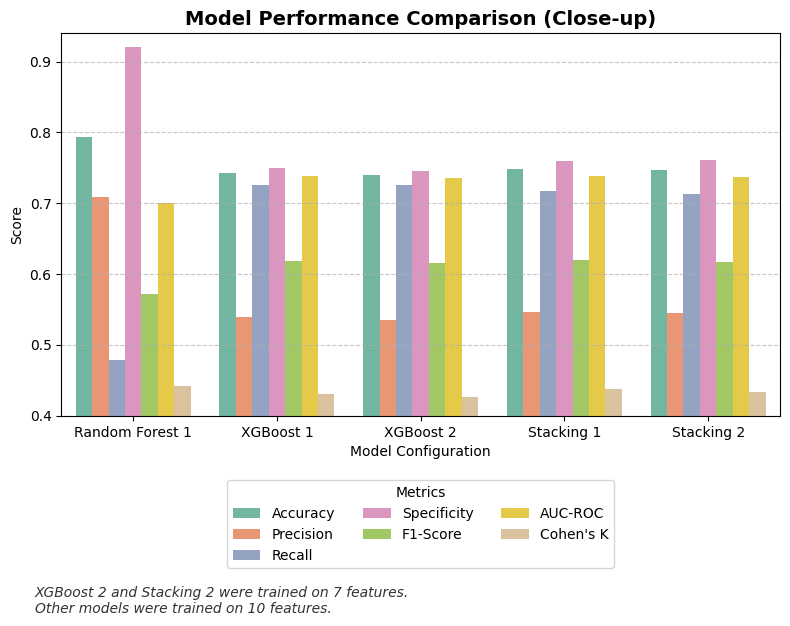

In [144]:
plt.figure(figsize=(8, 6))
sns.barplot(data=comparison_closeup_melted, x="Model", y="Score", hue="Metric", palette="Set2")
plt.title("Model Performance Comparison (Close-up)", fontsize=14, fontweight="bold")
plt.ylim(0.4, 0.94); plt.ylabel("Score"); plt.xlabel("Model Configuration")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, title="Metrics")
plt.grid(axis="y", linestyle="--", alpha=0.7)
caption_text = (
    "XGBoost 2 and Stacking 2 were trained on 7 features. \n"
    "Other models were trained on 10 features."
)
plt.figtext(0.05, -0.03, caption_text, ha="left", fontsize=10, fontstyle="italic", color="#333333")
plt.tight_layout(); plt.show()

---

In [ ]:
stop here

# Applying Risk Labels <a id='risk_labels'> </a>

<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2f))</span>

In [ ]:
y_proba22 = stacking_model13.predict_proba(X2_test)[:, 1]
low_t, med_t = determine_best_risk_thresholds(y_proba22, y2_test, low_risk_thresholds, med_risk_thresholds, chosen_metric='recall_high')

In [ ]:
churn_risk_df = churn_df.copy()
churn_risk_df = churn_risk_df[feature_list2]
y_proba13 = stacking_model13.predict_proba(churn_risk_df)
churn_risk_df['churn_probability'] = y_proba13[:, 1]

print(f"""
Predicted Churn Probabilities in Churn dataset:

Below 30: {(churn_risk_df[churn_risk_df['churn_probability'] < 0.3].shape[0] / churn_risk_df.shape[0]) * 100:.2f}%
Between 30 and 40: {(churn_risk_df[(churn_risk_df['churn_probability'] >= 0.3) & (churn_risk_df['churn_probability'] <= 0.4)].shape[0] / churn_risk_df.shape[0]) * 100:.2f}%
41 and above: {(churn_risk_df[churn_risk_df['churn_probability'] >= 0.41].shape[0] / churn_risk_df.shape[0]) * 100:.2f}%

How much of the 41 and above are also where Churned = 1?

{(churn_risk_df[(churn_risk_df['churn_probability'] >= 0.41) & (churn_df['Churned'] == 1)].shape[0] / churn_risk_df[churn_risk_df['churn_probability'] >= 0.41].shape[0]) * 100:.2f}%
""")

In [ ]:
churn_risk_df['Churn_Risk'] = churn_risk_df.apply(apply_risk_label, axis=1)

In [ ]:
churn_risk_df.head(5)

In [ ]:
print(f"""
Predicted Churn Probabilities in Churn dataset:

Labeled as Low and Churned = 1
{(churn_risk_df[(churn_risk_df['Churn_Risk'] == 'Low') & (churn_df['Churned'] == 1)].shape[0] / churn_risk_df[churn_risk_df['Churn_Risk'] == 'Low'].shape[0]) * 100:.2f}%

Labeled as Medium and Churned = 1
{(churn_risk_df[(churn_risk_df['Churn_Risk'] == 'Medium') & (churn_df['Churned'] == 1)].shape[0] / churn_risk_df[churn_risk_df['Churn_Risk'] == 'Medium'].shape[0]) * 100:.2f}%

Labeled as High and Churned = 1
{(churn_risk_df[(churn_risk_df['Churn_Risk'] == 'High') & (churn_df['Churned'] == 1)].shape[0] / churn_risk_df[churn_risk_df['Churn_Risk'] == 'High'].shape[0]) * 100:.2f}%

Missing rows in Churn_Risk column: {churn_risk_df['Churn_Risk'].isna().sum()}
""")